# Peak EV demand vs adoption rate

Sweep occupied housing-stock EV adoption $\tau \in \{0, 5, \ldots, 100\}\%$ under
`utils/EVs/configs/md_2024.yaml` and plot **annual peak hourly residential EV charging
load** (and **base + EV** total peak) for **all four charging policies** (ResStock
`weight`-weighted).

**Scenario** (from the YAML): simulation calendar **2018** (non-leap, AMY2018-aligned);
BGE Schedule EV **summer** peak hours and SOS prices applied **year-round** on
weekdays only (`peak_clock_hours` 10–19; weekends off-peak; **holidays not special**).
`off_peak_immediate` allows **emergency on-peak charging** when a rolling **48-hour**
off-peak-only forecast would underflow.

**Strategies** (cached together): `immediate`, `off_peak`, `off_peak_immediate`,
`cost_minimizing`. Strategy knobs (`soc_min_fraction`, prices, emergency flag, …)
live in the YAML even when the active `charging_strategy` is only one of the four.

**Method**
1. Load (or build) a $\tau=100\%$ per-building hourly `charge_kwh` cache for all
   strategies via `dev/build_adoption_peak_cache.py` (trips once; SOC per strategy).
2. For each $\tau$, re-sample nested EV sets with `EVAdoptionSampler(target_adoption_rate=τ)`
   (same `random_state` ⇒ EV sets nest as $\tau$ rises).
3. Peak($\tau$, strategy) = $\max_t \sum_{i \in S_\tau} w_i \cdot \mathrm{charge}_{i,t}$.

**Cache workflow**
- Prefer: `uv run python dev/build_adoption_peak_cache.py` once (multi-strategy; longer
  than the old single-strategy cache because of `cost_minimizing` LPs), then run this
  notebook (loads cache, sweeps in seconds).
- Or: set `FORCE_REBUILD_CACHE = True` / delete the cache and let the load cell build it.

Buildings that fail battery/charger feasibility at 100% are skipped (contribute 0 load).
SOC **underflow hours** (trip draw exceeding available SOC) are cached per strategy and
reported in §1b — rebuild the cache once if `underflow_hours_by_strategy.npz` is missing.
For a smoke *rebuild* only, set `MAX_BUILDINGS` (ignored when loading an existing full cache).


In [1]:
import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

BSF_ROOT = Path("/ebs/home/lily_switch_box/buildstock-fetch")
if str(BSF_ROOT) not in sys.path:
    sys.path.insert(0, str(BSF_ROOT))

from utils.EVs.EVAdoptionSampler import EVAdoptionSampler
from utils.EVs.charging import build_is_off_peak
from utils.EVs.ev_demand import load_ev_demand_config, resolve_hourly_prices
from utils.EVs import ev_utils

# Cache build/load lives in one place — notebook imports it rather than duplicating.
from dev.build_adoption_peak_cache import (
    CHARGING_STRATEGIES,
    adoption_peak_cache_dir,
    load_or_build_charge_cache,
    strategy_energy_underflow_summary,
)

logging.basicConfig(level=logging.WARNING, format="%(asctime)s - %(levelname)s - %(message)s")

COLOR_PINK = "#D86ECC"
COLOR_GREEN = "#3B7D23"
STRATEGY_COLORS = {
    "immediate": COLOR_PINK,
    "off_peak": "#6B8E23",
    "off_peak_immediate": COLOR_GREEN,
    "cost_minimizing": "#555555",
}
STRATEGY_LABELS = {
    "immediate": "immediate",
    "off_peak": "off_peak",
    "off_peak_immediate": "off_peak_immediate",
    "cost_minimizing": "cost_minimizing",
}


In [2]:
# --- knobs ---
CONFIG_PATH = BSF_ROOT / "utils/EVs/configs/md_2024.yaml"
# Only used when *building* a new cache (smoke test). Ignored if cache already exists
# unless FORCE_REBUILD_CACHE is True.
MAX_BUILDINGS: int | None = None
FORCE_REBUILD_CACHE = False
GEN_BATCH_SIZE = 50

ADOPTION_RATES = np.round(np.arange(0.0, 1.0 + 1e-9, 0.05), 2)

config = load_ev_demand_config(CONFIG_PATH)
SEED = config.random_state
STATE = config.state
CACHE_DIR = adoption_peak_cache_dir(config, root=BSF_ROOT)

print(f"state={STATE}  release={config.release}  seed={SEED}")
print(f"sim window: {config.start_date} → {config.end_date}")
print(f"config.charging_strategy={config.charging_strategy} (plots use all {len(CHARGING_STRATEGIES)})")
print(f"strategies={list(CHARGING_STRATEGIES)}")
print(
    f"TOU: year-round peak_clock_hours={list(config.peak_clock_hours or [])}  "
    f"weekends_off_peak={config.tou_weekends_off_peak}  "
    f"holidays_off_peak={config.tou_holidays_off_peak}"
)
print(
    f"SOS prices ($/kWh): on={config.tou_on_peak_price_summer_usd_per_kwh}  "
    f"off={config.tou_off_peak_price_summer_usd_per_kwh}  "
    f"(winter fields mirror summer)"
)
print(
    f"allow_emergency_peak_charging={config.allow_emergency_peak_charging}  "
    f"(48h off-peak-only foresight for off_peak_immediate)"
)
print(f"cache_dir={CACHE_DIR}")
print(f"adoption grid: {ADOPTION_RATES[0]:.0%} … {ADOPTION_RATES[-1]:.0%} ({len(ADOPTION_RATES)} steps)")
print(f"MAX_BUILDINGS={MAX_BUILDINGS}  FORCE_REBUILD_CACHE={FORCE_REBUILD_CACHE}")


2026-08-20 20:23:30,097 - WARNING - charging_strategy=off_peak_immediate ignores soc_min_fraction, soc_safety_buffer_fraction, shed_load_penalty_usd_per_kwh, prices (fills to full on off-peak home hours; does not use SOC_req)


state=MD  release=res_2024_tmy3_2  seed=42
sim window: 2018-01-01 04:00:00 → 2019-01-01 03:00:00
config.charging_strategy=off_peak_immediate (plots use all 4)
strategies=['immediate', 'off_peak', 'off_peak_immediate', 'cost_minimizing']
TOU: year-round peak_clock_hours=[10, 11, 12, 13, 14, 15, 16, 17, 18, 19]  weekends_off_peak=True  holidays_off_peak=False
SOS prices ($/kWh): on=0.23636  off=0.09981  (winter fields mirror summer)
allow_emergency_peak_charging=True  (48h off-peak-only foresight for off_peak_immediate)
cache_dir=/ebs/home/lily_switch_box/buildstock-fetch/utils/EVs/ev_data/outputs/MD_res_2024_tmy3_2/adoption_peak_sweep
adoption grid: 0% … 100% (21 steps)
MAX_BUILDINGS=None  FORCE_REBUILD_CACHE=False


In [3]:
inputs = ev_utils.load_all_input_data(config)
metadata_df = inputs.metadata_df
# Adoption sweep uses this frame. Keep full MD when loading a full cache.
if MAX_BUILDINGS is not None and FORCE_REBUILD_CACHE:
    metadata_df = metadata_df.head(MAX_BUILDINGS)

occupied = (
    metadata_df.filter(~pl.col("is_vacant"))
    if "is_vacant" in metadata_df.columns
    else metadata_df
)
total_weight = float(occupied["weight"].sum())

print(f"buildings={metadata_df.height:,}  occupied={occupied.height:,}")
print(f"occupied stock weight sum={total_weight:,.1f}")
assert config.ev_assignment == "resstock_adoption"
assert inputs.ev_ownership_df is not None


2026-08-20 20:23:30,406 - INFO - NHTS households (division 5, HHVEHCNT>0): 1491
2026-08-20 20:23:30,428 - INFO - NHTS light-duty vehicle-days (owner HH × inventory): 2727 vehicles across 1487 HH
2026-08-20 20:23:30,460 - INFO - NHTS OUTOFTWN filter (keep 02=not away entire day): 3946/3979 driver trip rows retained
2026-08-20 20:23:30,464 - INFO - NHTS home-touch filter (any WHYFROM or WHYTO in [1, 2]): 3929/3946 trip rows, 1362 vehicles with usable driven days
2026-08-20 20:23:30,467 - INFO - NHTS vehicle-day split: 1362 usable driven, 1343 empty (idle), 22 excluded (had driver trips but failed OUTOFTWN/home-touch)
2026-08-20 20:23:30,470 - INFO - NHTS match pool: 3929 rows (3929 driven trip legs, 0 empty vehicle-days) across 1362 vehicles / 1085 households
2026-08-20 20:23:30,664 - INFO - Preloaded 24 weather station CSV(s) from /ebs/home/lily_switch_box/buildstock-fetch/utils/EVs/ev_data/inputs/res_2024_tmy3_2/weather/MD


buildings=9,001  occupied=9,001
occupied stock weight sum=2,270,967.1


## 1. Load or build $\tau = 100\%$ hourly charge matrices (all strategies)

Calls `load_or_build_charge_cache` from `dev/build_adoption_peak_cache.py`.
Writes / loads `charge_kwh_by_strategy.npz` (float32 charge) and
`underflow_hours_by_strategy.npz` (int32 per-vehicle SOC underflow hour counts).
If the multi-strategy cache exists (and `FORCE_REBUILD_CACHE` is false), this is a fast disk read.
Legacy single-strategy `charge_kwh_f32.npy` caches must be rebuilt; caches without the
underflow sidecar still load but §1b will prompt a rebuild for underflow totals.


In [4]:
cache = load_or_build_charge_cache(
    config,
    force_rebuild=FORCE_REBUILD_CACHE,
    inputs=inputs,
    metadata_df=metadata_df if FORCE_REBUILD_CACHE else None,
    max_buildings=MAX_BUILDINGS if FORCE_REBUILD_CACHE else None,
    batch_size=GEN_BATCH_SIZE,
    cache_dir=CACHE_DIR,
    root=BSF_ROOT,
)

charge_by_strategy = cache.charge_by_strategy
underflow_hours_by_strategy = cache.underflow_hours_by_strategy
building_meta = cache.building_meta
hours_base = cache.hours_base
failed_df = cache.failed_df
# Convenience alias (default / config strategy) for any single-matrix callers.
charge_mat = cache.charge_mat

weights = building_meta["weight"].to_numpy().astype(np.float64)
bldg_ids = building_meta["bldg_id"].to_numpy()
bldg_id_to_row = {int(b): i for i, b in enumerate(bldg_ids.tolist())}
print(
    f"Stock weight covered={weights.sum():,.1f} / {total_weight:,.1f} "
    f"({weights.sum() / total_weight:.1%} of occupied)"
)
for strategy, mat in charge_by_strategy.items():
    line = f"  {strategy}: shape={mat.shape} mean_charge={float(mat.mean()):.4f} kWh/h"
    if cache.underflow_available:
        line += f" underflow_hours={int(underflow_hours_by_strategy[strategy].sum())}"
    print(line)
if not cache.underflow_available:
    print(
        "  (underflow hours not in cache — rebuild to populate "
        "underflow_hours_by_strategy.npz)"
    )
if failed_df.height:
    display(failed_df.head(10))


Loaded multi-strategy cache: 9,001 buildings × 8,760 hours × 4 strategies (320.0 MB)
strategies=['immediate', 'off_peak', 'off_peak_immediate', 'cost_minimizing']
Skipped infeasible buildings: 0
underflow_hours={'immediate': 0, 'off_peak': 38179, 'off_peak_immediate': 32, 'cost_minimizing': 1}
Stock weight covered=2,270,967.1 / 2,270,967.1 (100.0% of occupied)
  immediate: shape=(9001, 8760) mean_charge=0.2102 kWh/h underflow_hours=0
  off_peak: shape=(9001, 8760) mean_charge=0.2030 kWh/h underflow_hours=38179
  off_peak_immediate: shape=(9001, 8760) mean_charge=0.2101 kWh/h underflow_hours=32
  cost_minimizing: shape=(9001, 8760) mean_charge=0.2025 kWh/h underflow_hours=1


## 1b. Matching / feasibility diagnostics

Hard failures from the τ=100% charge cache, **per-strategy SOC underflow hours** (same
metric as `ev_presentation.ipynb`: hours where trip draw exceeds available SOC), plus a
fresh NHTS match catalog at the same seed/config (`return_catalog=True`). Empty trip
templates are intentional idle days when enabled — not match failures. Match-type
fallbacks mean a looser demographic tier was used.


In [5]:
from dataclasses import replace

from utils.EVs.ev_demand import EVDemandCalculator
from utils.EVs.NHTSProfileSampler import summarize_nhts_match_catalog

# --- Hard failures recorded while building the charge cache ---
print("=== Charge-cache hard failures (battery / charger) ===")
print(f"failed_buildings.parquet rows: {failed_df.height:,}")
print(f"charge-cache buildings: {building_meta.height:,}  metadata: {metadata_df.height:,}")
if failed_df.height:
    display(failed_df)
else:
    print("No buildings skipped for battery/charger infeasibility.")

# --- SOC underflow hours by strategy (τ=100% fleet, unweighted vehicle-hours) ---
print("\n=== SOC underflow hours by charging strategy (τ=100%) ===")
if cache.underflow_available:
    uf_summary = strategy_energy_underflow_summary(cache)
    for row in uf_summary.iter_rows(named=True):
        discharge = row["annual_discharge_kwh"]
        discharge_s = (
            f"{discharge:,.1f} kWh" if discharge is not None else "n/a (rebuild cache)"
        )
        print(
            f"{row['strategy']:20s}  annual charge={row['annual_charge_kwh']:10,.1f} kWh  "
            f"discharge={discharge_s:>16s}  "
            f"underflow_hours={row['underflow_hours']:,}  "
            f"vehicles_with_underflow={row['n_vehicles_with_underflow']:,}"
        )
    display(uf_summary)
else:
    print(
        "underflow_hours_by_strategy.npz not found — rebuild the charge cache "
        "(FORCE_REBUILD_CACHE=True or `uv run python dev/build_adoption_peak_cache.py`)."
    )

# --- NHTS matching catalog at τ=100% (same path as cache generation) ---
print("\n=== NHTS profile matching (τ=100%, return_catalog=True) ===")
config_full = replace(config, target_adoption_rate=1.0)
calc_diag = EVDemandCalculator.from_config(
    config_full,
    metadata_df=metadata_df,
    nhts_df=inputs.nhts_df,
    ev_ownership_df=inputs.ev_ownership_df,
    ev_battery_df=inputs.ev_battery_df,
    ev_autonomie_df=inputs.ev_autonomie_df,
    ev_charger_df=inputs.ev_charger_df,
    ev_charge_at_home_df=inputs.ev_charge_at_home_df,
    weather_map=inputs.weather_map,
    station_temps=inputs.station_temps,
)
bldg_veh_diag = calc_diag._assign_ev_slots()
n_ev_slots = int((bldg_veh_diag["vehicles"] > 0).sum())
print(f"EV slots assigned: {n_ev_slots:,} / {bldg_veh_diag.height:,} buildings")

_profiles, match_catalog = calc_diag.nhts_sampler.sample(
    bldg_veh_diag, return_catalog=True
)
print(f"Profiles returned: {len(_profiles):,}  catalog rows: {match_catalog.height:,}")

match_summary = summarize_nhts_match_catalog(match_catalog)
display(match_summary)

weekday_tiers = (
    match_catalog.group_by("weekday_match_type")
    .agg(pl.len().alias("n"))
    .with_columns((pl.col("n") / match_catalog.height).round(4).alias("share"))
    .sort("n", descending=True)
)
weekend_tiers = (
    match_catalog.group_by("weekend_match_type")
    .agg(pl.len().alias("n"))
    .with_columns((pl.col("n") / match_catalog.height).round(4).alias("share"))
    .sort("n", descending=True)
)
print("Weekday match tiers:")
display(weekday_tiers)
print("Weekend match tiers:")
display(weekend_tiers)

n_missing = int((~match_catalog["nhts_vehicle_matched"]).sum())
n_idle_both = int(
    (
        (~match_catalog["has_weekday_trips"]) & (~match_catalog["has_weekend_trips"])
    ).sum()
)
print(
    f"\nmissing_nhts_vehicle_match={n_missing}  "
    f"empty_both_trip_profiles={n_idle_both} "
    f"({n_idle_both / max(match_catalog.height, 1):.2%})"
)


=== Charge-cache hard failures (battery / charger) ===
failed_buildings.parquet rows: 0
charge-cache buildings: 9,001  metadata: 9,001
No buildings skipped for battery/charger infeasibility.

=== SOC underflow hours by charging strategy (τ=100%) ===


immediate             annual charge=16,571,540.0 kWh  discharge=16,576,052.0 kWh  underflow_hours=0  vehicles_with_underflow=0
off_peak              annual charge=16,008,704.0 kWh  discharge=16,576,052.0 kWh  underflow_hours=38,179  vehicles_with_underflow=850
off_peak_immediate    annual charge=16,567,932.0 kWh  discharge=16,576,052.0 kWh  underflow_hours=32  vehicles_with_underflow=6
cost_minimizing       annual charge=15,963,095.0 kWh  discharge=16,576,052.0 kWh  underflow_hours=1  vehicles_with_underflow=1


strategy,annual_charge_kwh,annual_discharge_kwh,underflow_hours,n_vehicles_with_underflow
str,f64,f64,i64,i64
"""immediate""",1.657154e7,1.6576052e7,0,0
"""off_peak""",1.6008704e7,1.6576052e7,38179,850
"""off_peak_immediate""",1.6567932e7,1.6576052e7,32,6
"""cost_minimizing""",1.5963095e7,1.6576052e7,1,1


2026-08-20 20:23:35,242 - WARNING - charging_strategy=off_peak_immediate ignores soc_min_fraction, soc_safety_buffer_fraction, shed_load_penalty_usd_per_kwh, prices (fills to full on off-peak home hours; does not use SOC_req)
2026-08-20 20:23:35,244 - INFO - Sampling EV ownership from ResStock adoption rates (max 1 EV per household; match_on_vehicles=False)
2026-08-20 20:23:35,250 - INFO - Sampling vehicle profiles for 9001 buildings...
2026-08-20 20:23:35,253 - INFO - Preparing NHTS weekday matching cache...



=== NHTS profile matching (τ=100%, return_catalog=True) ===
EV slots assigned: 9,001 / 9,001 buildings


...

Weekday match tiers:


weekday_match_type,n,share
str,u32,f64
"""urban_income_occupants""",8999,0.9998
"""urban_occupants""",2,0.0002


Weekend match tiers:


weekend_match_type,n,share
str,u32,f64
"""urban_income_occupants""",8999,0.9998
"""urban_occupants""",2,0.0002



missing_nhts_vehicle_match=0  empty_both_trip_profiles=0 (0.00%)


## 2. Nested adoption sweep → annual peak load (per strategy)

Same seed as the config ⇒ priority-sampled EV sets nest: \(S_{0.05} \subset S_{0.10} \subset \cdots\).
For each strategy, peak is the max over the year of the weight-weighted sum of `charge_kwh`.


In [6]:
# Precompute nested EV id sets for each τ (adoption only — cheap).
ev_ids_by_tau: dict[float, set[int]] = {}
prev: set[int] | None = None
for tau in ADOPTION_RATES:
    if tau == 0.0:
        ev_ids = set()
    else:
        sampled = EVAdoptionSampler(
            ev_ownership_df=inputs.ev_ownership_df,
            random_state=SEED,
            target_adoption_rate=float(tau),
        ).sample(metadata_df)
        ev_ids = set(
            sampled.filter(pl.col("evs") == 1)["bldg_id"].to_list()
        )
    if prev is not None and not prev.issubset(ev_ids):
        raise AssertionError(f"EV sets not nested at τ={tau}")
    ev_ids_by_tau[float(tau)] = ev_ids
    prev = ev_ids

    # Realized stock share among full metadata (denominator = all occupied weight)
    if tau == 0.0:
        realized = 0.0
    else:
        w_ev = float(
            metadata_df.filter(pl.col("bldg_id").is_in(list(ev_ids)))["weight"].sum()
        )
        realized = w_ev / total_weight
    print(f"τ={tau:5.0%}  n_ev={len(ev_ids):5,}  realized_stock_share={realized:6.2%}")

print("nesting OK")

τ=   0%  n_ev=    0  realized_stock_share= 0.00%
τ=   5%  n_ev=  451  realized_stock_share= 5.01%
τ=  10%  n_ev=  901  realized_stock_share=10.01%
τ=  15%  n_ev=1,351  realized_stock_share=15.01%
τ=  20%  n_ev=1,801  realized_stock_share=20.01%
τ=  25%  n_ev=2,251  realized_stock_share=25.01%
τ=  30%  n_ev=2,701  realized_stock_share=30.01%
τ=  35%  n_ev=3,151  realized_stock_share=35.01%
τ=  40%  n_ev=3,601  realized_stock_share=40.01%
τ=  45%  n_ev=4,051  realized_stock_share=45.01%
τ=  50%  n_ev=4,501  realized_stock_share=50.01%
τ=  55%  n_ev=4,951  realized_stock_share=55.00%
τ=  60%  n_ev=5,401  realized_stock_share=60.00%
τ=  65%  n_ev=5,851  realized_stock_share=65.00%
τ=  70%  n_ev=6,301  realized_stock_share=70.00%
τ=  75%  n_ev=6,751  realized_stock_share=75.00%
τ=  80%  n_ev=7,201  realized_stock_share=80.00%
τ=  85%  n_ev=7,651  realized_stock_share=85.00%
τ=  90%  n_ev=8,101  realized_stock_share=90.00%
τ=  95%  n_ev=8,551  realized_stock_share=95.00%
τ= 100%  n_ev=9,001 

In [7]:
timestamps = hours_base["timestamp"].to_list()

peak_rows = []
for strategy in CHARGING_STRATEGIES:
    charge_mat_s = charge_by_strategy[strategy]
    for tau in ADOPTION_RATES:
        ev_ids = ev_ids_by_tau[float(tau)]
        rows = [bldg_id_to_row[b] for b in ev_ids if b in bldg_id_to_row]
        n_missing = sum(1 for b in ev_ids if b not in bldg_id_to_row)

        if not rows:
            peak_kwh = 0.0
            peak_hour_idx = 0
            mean_kwh = 0.0
            p95_kwh = 0.0
            stock_w = 0.0
        else:
            idx = np.asarray(rows, dtype=np.int64)
            load = weights[idx] @ charge_mat_s[idx]
            peak_hour_idx = int(np.argmax(load))
            peak_kwh = float(load[peak_hour_idx])
            mean_kwh = float(load.mean())
            p95_kwh = float(np.quantile(load, 0.95))
            stock_w = float(weights[idx].sum())

        peak_rows.append(
            {
                "strategy": strategy,
                "adoption_rate": float(tau),
                "n_ev_assigned": len(ev_ids),
                "n_ev_with_charge": len(rows),
                "n_ev_missing_charge": n_missing,
                "ev_stock_weight": stock_w,
                "realized_stock_share": stock_w / total_weight,
                "peak_charge_kwh": peak_kwh,
                "peak_charge_mw": peak_kwh / 1000.0,
                "mean_hourly_charge_kwh": mean_kwh,
                "p95_hourly_charge_kwh": p95_kwh,
                "peak_hour_index": peak_hour_idx,
                "peak_timestamp": timestamps[peak_hour_idx],
                "peak_per_ev_kwh": peak_kwh / len(rows) if rows else 0.0,
                "peak_per_stock_share_kwh": (
                    peak_kwh / (stock_w / total_weight) if stock_w > 0 else 0.0
                ),
            }
        )

peak_df = pl.DataFrame(peak_rows)
display(peak_df)
# Wide peek: peak MW by τ × strategy
display(
    peak_df.pivot(
        on="strategy",
        index="adoption_rate",
        values="peak_charge_mw",
    ).sort("adoption_rate")
)


strategy,adoption_rate,n_ev_assigned,n_ev_with_charge,n_ev_missing_charge,ev_stock_weight,realized_stock_share,peak_charge_kwh,peak_charge_mw,mean_hourly_charge_kwh,p95_hourly_charge_kwh,peak_hour_index,peak_timestamp,peak_per_ev_kwh,peak_per_stock_share_kwh
str,f64,i64,i64,i64,f64,f64,f64,f64,f64,f64,i64,datetime[μs],f64,f64
"""immediate""",0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,2018-01-01 04:00:00,0.0,0.0
"""immediate""",0.05,451,451,0,113788.039067,0.050106,98743.74073,98.743741,26268.992824,65790.643686,927,2018-02-08 19:00:00,218.943993,1.9707e6
"""immediate""",0.1,901,901,0,227323.776496,0.1001,187518.100578,187.518101,49919.166758,122614.823982,423,2018-01-18 19:00:00,208.122198,1.8733e6
"""immediate""",0.15,1351,1351,0,340859.513925,0.150094,273450.245529,273.450246,74834.123754,181739.769696,423,2018-01-18 19:00:00,202.405807,1.8219e6
"""immediate""",0.2,1801,1801,0,454395.251353,0.200089,371552.147256,371.552147,98615.160016,241617.055483,423,2018-01-18 19:00:00,206.303247,1.8569e6
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""cost_minimizing""",0.8,7201,7201,0,1.8168e6,0.800022,1.0021e6,1002.118653,377419.510552,759473.014472,887,2018-02-07 03:00:00,139.163818,1.2526e6
"""cost_minimizing""",0.85,7651,7651,0,1.9304e6,0.850017,1.0542e6,1054.215365,398067.954782,800322.684578,887,2018-02-07 03:00:00,137.787919,1.2402e6
"""cost_minimizing""",0.9,8101,8101,0,2.0439e6,0.900011,1.1082e6,1108.183532,419713.128701,843021.270383,887,2018-02-07 03:00:00,136.795893,1.2313e6


adoption_rate,immediate,off_peak,off_peak_immediate,cost_minimizing
f64,f64,f64,f64,f64
0.0,0.0,0.0,0.0,0.0
0.05,98.743741,249.105035,258.059325,68.529473
0.1,187.518101,473.012083,501.2538,130.6671
0.15,273.450246,717.454728,763.474284,197.15898
0.2,371.552147,947.957801,1010.900897,258.097001
…,…,…,…,…
0.8,1403.255705,3539.785603,3744.368554,1002.118653
0.85,1475.250331,3696.158671,3908.128293,1054.215365
0.9,1546.256375,3857.536092,4076.171362,1108.183532


## 3. Plots

Annual peak residential EV charging load vs adoption rate — **one line per charging
policy** — plus peak timing / intensity checks.


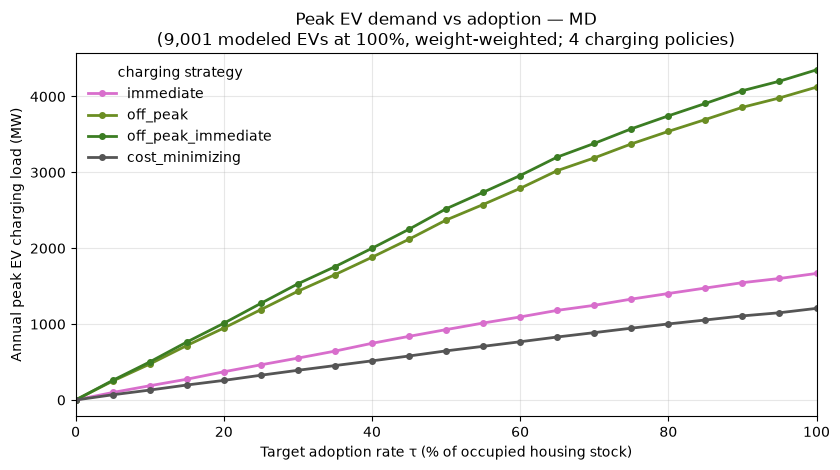

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
n_ev_100 = next(iter(charge_by_strategy.values())).shape[0]
for strategy in CHARGING_STRATEGIES:
    sub = peak_df.filter(pl.col("strategy") == strategy).sort("adoption_rate")
    ax.plot(
        sub["adoption_rate"].to_numpy() * 100,
        sub["peak_charge_mw"].to_numpy(),
        color=STRATEGY_COLORS[strategy],
        marker="o",
        linewidth=2,
        markersize=4,
        label=STRATEGY_LABELS[strategy],
    )
ax.set_xlabel("Target adoption rate τ (% of occupied housing stock)")
ax.set_ylabel("Annual peak EV charging load (MW)")
ax.set_title(
    f"Peak EV demand vs adoption — {STATE}\n"
    f"({n_ev_100:,} modeled EVs at 100%, weight-weighted; 4 charging policies)"
)
ax.set_xlim(0, 100)
ax.grid(True, alpha=0.3)
ax.legend(frameon=False, title="charging strategy")
fig.tight_layout()
plt.show()


### Robust peaks — $k$-th highest hour (EV-only)

Absolute annual max ($k=1$) can be dominated by a few extreme hours, so we also
plot **$k=10, 50, 100$**: if the strategy ranking flips away from $k=1$, the
absolute-max story was spike-driven. (With year-round TOU prices there is no
summer/winter season cliff; look instead for post-peak turn-on / overnight pile-ups.)

For each $\tau$ and strategy, sort the weight-weighted hourly EV load descending and
take the $k$-th entry (1-indexed).

A companion **EV share of residential demand** figure (at these same EV-peak hours) is plotted after the base-load section — it needs `base_t` at $t^*$.


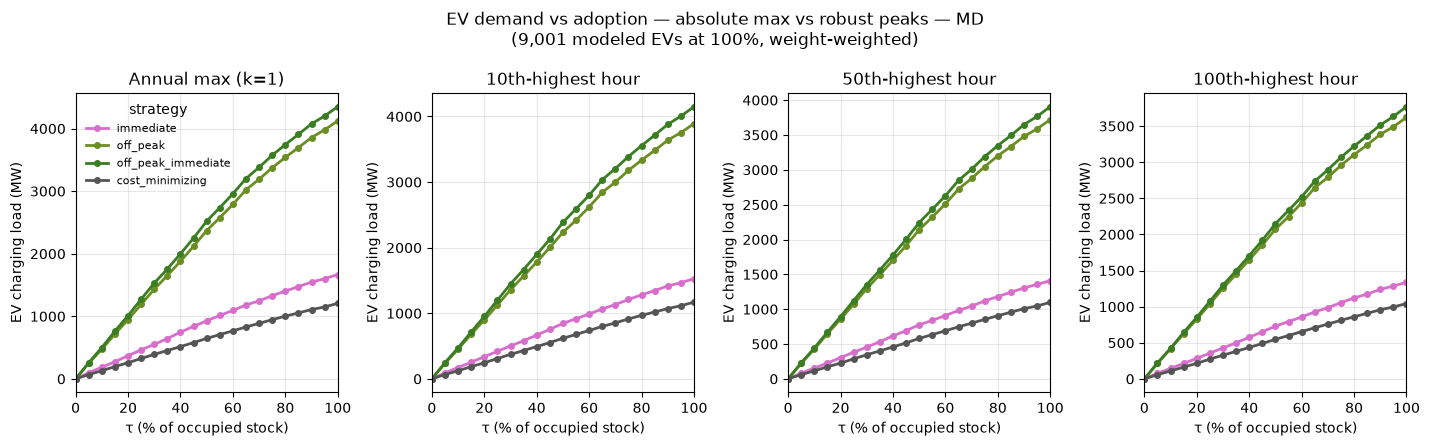

τ=100% k-th highest hour timestamps:


strategy,k,kth_charge_mw,kth_timestamp
str,i64,f64,datetime[μs]
"""cost_minimizing""",1,1207.442757,2018-02-07 03:00:00
"""cost_minimizing""",10,1170.184148,2018-02-07 00:00:00
"""cost_minimizing""",50,1098.303863,2018-02-14 01:00:00
"""cost_minimizing""",100,1043.437854,2018-01-22 03:00:00
"""immediate""",1,1667.839973,2018-01-18 19:00:00
…,…,…,…
"""off_peak""",100,3620.296003,2018-05-17 20:00:00
"""off_peak_immediate""",1,4351.021074,2018-01-18 20:00:00
"""off_peak_immediate""",10,4150.085855,2018-01-22 20:00:00


τ=100% EV load (MW) by k × strategy:


k,immediate,off_peak,off_peak_immediate,cost_minimizing
i64,f64,f64,f64,f64
1,1667.839973,4123.1863,4351.021074,1207.442757
10,1527.700599,3891.643548,4150.085855,1170.184148
50,1410.047349,3720.515831,3906.952546,1098.303863
100,1337.810263,3620.296003,3769.311885,1043.437854


In [9]:
# EV-only: k-th highest hourly load vs adoption (k=1 is the usual annual peak)
K_PEAKS = (1, 10, 50, 100)

kth_rows = []
for strategy in CHARGING_STRATEGIES:
    charge_mat_s = charge_by_strategy[strategy]
    for tau in ADOPTION_RATES:
        ev_ids = ev_ids_by_tau[float(tau)]
        rows = [bldg_id_to_row[b] for b in ev_ids if b in bldg_id_to_row]
        if not rows:
            load = np.zeros(len(timestamps), dtype=np.float64)
        else:
            idx = np.asarray(rows, dtype=np.int64)
            load = weights[idx] @ charge_mat_s[idx]

        # argsort descending → k-th highest at position k-1
        order = np.argsort(load)[::-1]
        for k in K_PEAKS:
            hour_idx = int(order[k - 1])
            kth_rows.append(
                {
                    "strategy": strategy,
                    "adoption_rate": float(tau),
                    "k": k,
                    "kth_charge_mw": float(load[hour_idx]) / 1000.0,
                    "kth_hour_index": hour_idx,
                    "kth_timestamp": timestamps[hour_idx],
                }
            )

kth_df = pl.DataFrame(kth_rows)

fig, axes = plt.subplots(1, len(K_PEAKS), figsize=(3.6 * len(K_PEAKS), 4.5), sharey=False)
n_ev_100 = next(iter(charge_by_strategy.values())).shape[0]
for ax, k in zip(axes, K_PEAKS):
    for strategy in CHARGING_STRATEGIES:
        sub = kth_df.filter(
            (pl.col("strategy") == strategy) & (pl.col("k") == k)
        ).sort("adoption_rate")
        ax.plot(
            sub["adoption_rate"].to_numpy() * 100,
            sub["kth_charge_mw"].to_numpy(),
            color=STRATEGY_COLORS[strategy],
            marker="o",
            linewidth=2,
            markersize=4,
            label=STRATEGY_LABELS[strategy],
        )
    title = "Annual max (k=1)" if k == 1 else f"{k}th-highest hour"
    ax.set_title(title)
    ax.set_xlabel("τ (% of occupied stock)")
    ax.set_xlim(0, 100)
    ax.grid(True, alpha=0.3)

for _ax in axes:
    _ax.set_ylabel("EV charging load (MW)")
axes[0].legend(frameon=False, fontsize=8, title="strategy")
fig.suptitle(
    f"EV demand vs adoption — absolute max vs robust peaks — {STATE}\n"
    f"({n_ev_100:,} modeled EVs at 100%, weight-weighted)",
    fontsize=12,
)
fig.tight_layout()
plt.show()

# τ=100% timestamps for each k — see whether extremes are the same hour family
print("τ=100% k-th highest hour timestamps:")
display(
    kth_df.filter(pl.col("adoption_rate") == 1.0)
    .select("strategy", "k", "kth_charge_mw", "kth_timestamp")
    .sort("strategy", "k")
)

# Wide MW table at τ=100%
print("τ=100% EV load (MW) by k × strategy:")
display(
    kth_df.filter(pl.col("adoption_rate") == 1.0)
    .pivot(on="strategy", index="k", values="kth_charge_mw")
    .sort("k")
)


### Peak-hour diagnosis (EV-only, τ=100%) — $k \in \{1, 10, 50, 100\}$

For each strategy’s **$k$-th highest** EV-only hour (same $k$ as the robust-peak
plots), report:

1. Calendar context — weekday, month, BGE TOU on/off-peak, SOS price
2. Vehicle participation — how many EVs charge, mean/p95 kWh in that hour
3. Cross-strategy load at the same timestamp
4. ±12 h profiles around that hour (one 2×2 panel per $k$)
5. Daily fleet charge energy on the peak day ± a few days — stockpiling vs normal duty?

Compare $k=1$ vs $k=10$ vs $k=50/100$: does the peak stay on-peak / at the 8pm
off-peak turn-on, or move into ordinary overnight off-peak hours?


EV-only k-th hour forensics @ τ=100%  (9,001 EVs)
TOU: year-round peak hours=[10, 11, 12, 13, 14, 15, 16, 17, 18, 19]  weekends_off_peak=True  holidays_off_peak=False  emergency_48h=True


strategy,k,timestamp,weekday,month,clock_hour,tou_label,price_usd_per_kwh,mechanism,mw,n_ev_charging,share_ev_charging,mean_charge_kwh_if_charging,p95_charge_kwh_if_charging,max_charge_kwh
str,i64,datetime[μs],str,i64,i64,str,f64,str,f64,i64,f64,f64,f64,f64
"""immediate""",1,2018-01-18 19:00:00,"""Thursday""",1,19,"""on-peak""",0.23636,"""on_peak_charging""",1667.839973,3049,0.33874,2.168088,7.2,7.2
"""immediate""",10,2018-01-18 18:00:00,"""Thursday""",1,18,"""on-peak""",0.23636,"""on_peak_charging""",1527.700599,2820,0.313299,2.147183,7.2,7.2
"""immediate""",50,2018-12-26 18:00:00,"""Wednesday""",12,18,"""on-peak""",0.23636,"""on_peak_charging""",1410.047349,2696,0.299522,2.072973,7.2,7.2
"""immediate""",100,2018-11-29 19:00:00,"""Thursday""",11,19,"""on-peak""",0.23636,"""on_peak_charging""",1337.810263,2673,0.296967,1.983698,7.2,7.2
"""off_peak""",1,2018-12-24 20:00:00,"""Monday""",12,20,"""off-peak""",0.09981,"""post_peak_window_turn_on""",4123.1863,6921,0.768915,2.361261,7.2,7.2
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""off_peak_immediate""",100,2018-11-15 20:00:00,"""Thursday""",11,20,"""off-peak""",0.09981,"""post_peak_window_turn_on""",3769.311885,7173,0.796911,2.082769,7.2,7.2
"""cost_minimizing""",1,2018-02-07 03:00:00,"""Wednesday""",2,3,"""off-peak""",0.09981,"""overnight_off_peak""",1207.442757,8473,0.94134,0.564818,1.6,6.866931
"""cost_minimizing""",10,2018-02-07 00:00:00,"""Wednesday""",2,0,"""off-peak""",0.09981,"""overnight_off_peak""",1170.184148,8328,0.925231,0.556919,1.589633,6.798638



Mechanism tags by strategy × k:


strategy,1,10,50,100
str,str,str,str,str
"""cost_minimizing""","""overnight_off_peak""","""overnight_off_peak""","""overnight_off_peak""","""overnight_off_peak"""
"""immediate""","""on_peak_charging""","""on_peak_charging""","""on_peak_charging""","""on_peak_charging"""
"""off_peak""","""post_peak_window_turn_on""","""post_peak_window_turn_on""","""post_peak_window_turn_on""","""post_peak_window_turn_on"""
"""off_peak_immediate""","""post_peak_window_turn_on""","""post_peak_window_turn_on""","""post_peak_window_turn_on""","""post_peak_window_turn_on"""



Fleet EV load (MW) at each strategy's k-th peak hour:


peak_owner,k,timestamp,mechanism,tou_label,immediate_mw,off_peak_mw,off_peak_immediate_mw,cost_minimizing_mw
str,i64,datetime[μs],str,str,f64,f64,f64,f64
"""immediate""",1,2018-01-18 19:00:00,"""on_peak_charging""","""on-peak""",1667.839973,0.0,0.403683,1.392512
"""immediate""",10,2018-01-18 18:00:00,"""on_peak_charging""","""on-peak""",1527.700599,0.0,0.807365,1.818319
"""immediate""",50,2018-12-26 18:00:00,"""on_peak_charging""","""on-peak""",1410.047349,0.0,1.211048,0.394391
"""immediate""",100,2018-11-29 19:00:00,"""on_peak_charging""","""on-peak""",1337.810263,0.0,0.0,0.147855
"""off_peak""",1,2018-12-24 20:00:00,"""post_peak_window_turn_on""","""off-peak""",1328.193383,4123.1863,4043.34704,745.034792
…,…,…,…,…,…,…,…,…
"""off_peak_immediate""",100,2018-11-15 20:00:00,"""post_peak_window_turn_on""","""off-peak""",1119.565518,3701.660751,3769.311885,742.022505
"""cost_minimizing""",1,2018-02-07 03:00:00,"""overnight_off_peak""","""off-peak""",435.139711,563.524068,645.075193,1207.442757
"""cost_minimizing""",10,2018-02-07 00:00:00,"""overnight_off_peak""","""off-peak""",816.441659,1261.862176,1343.384851,1170.184148


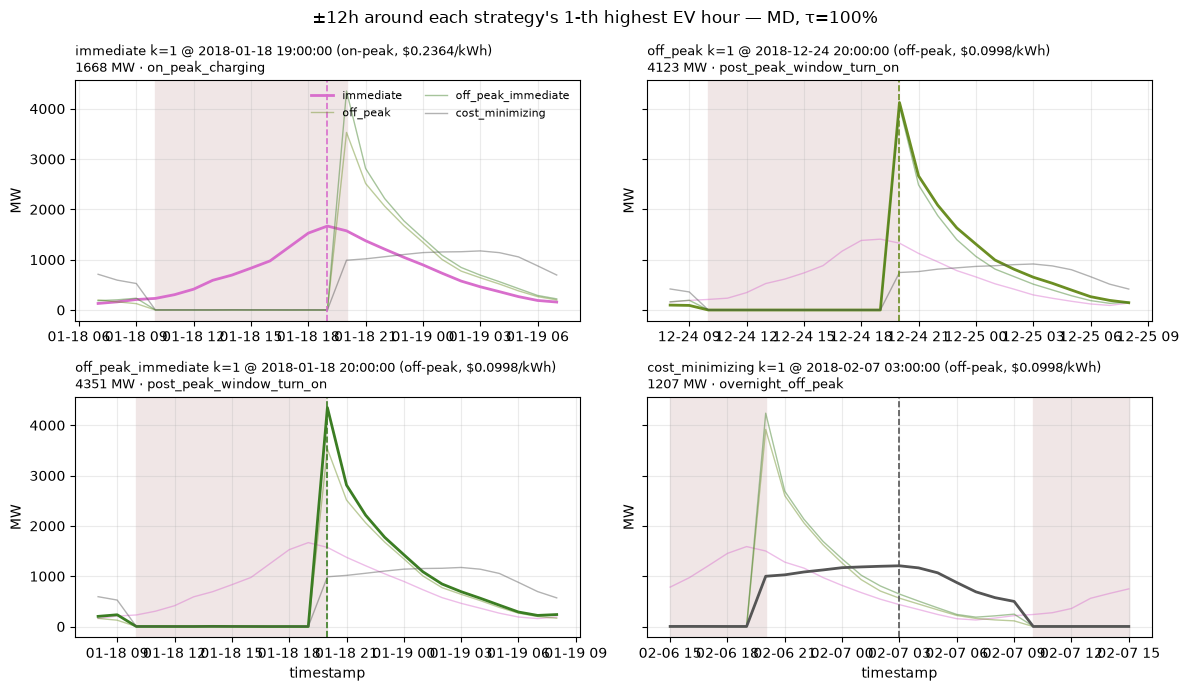

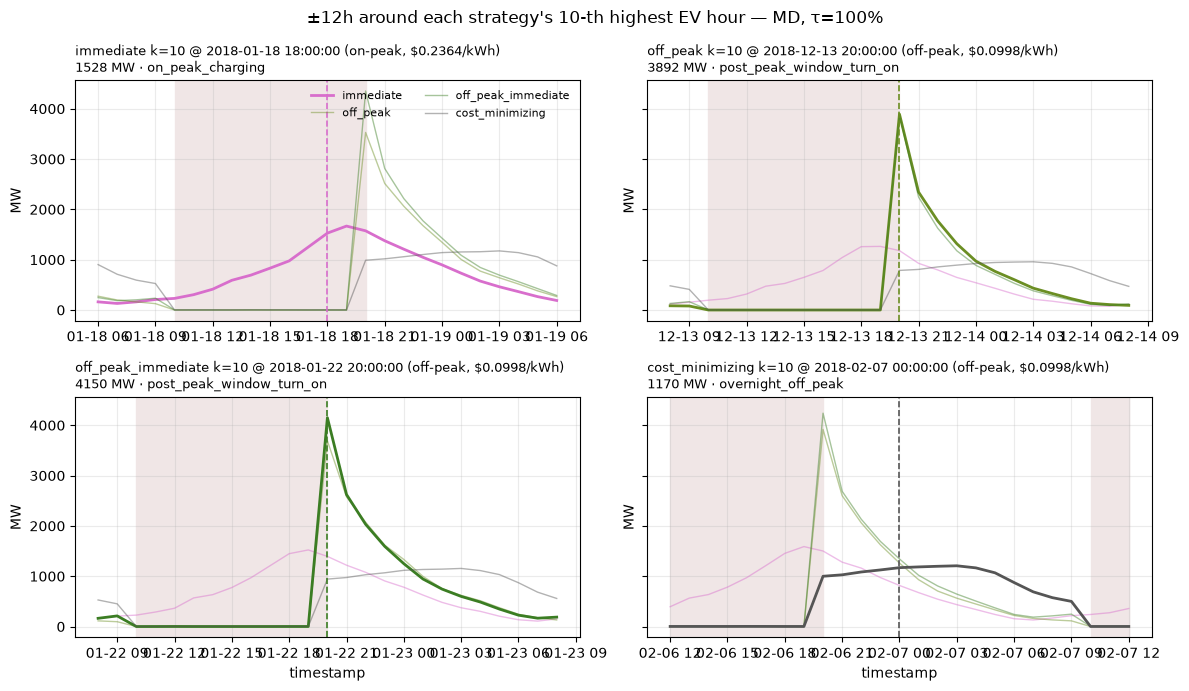

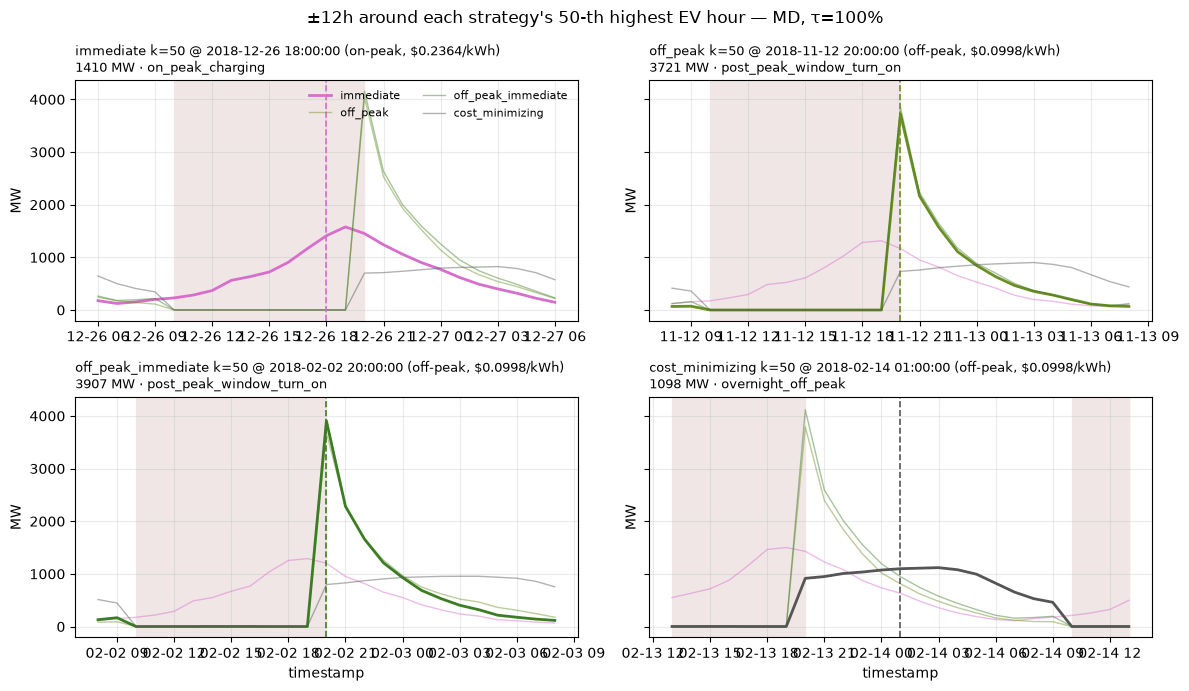

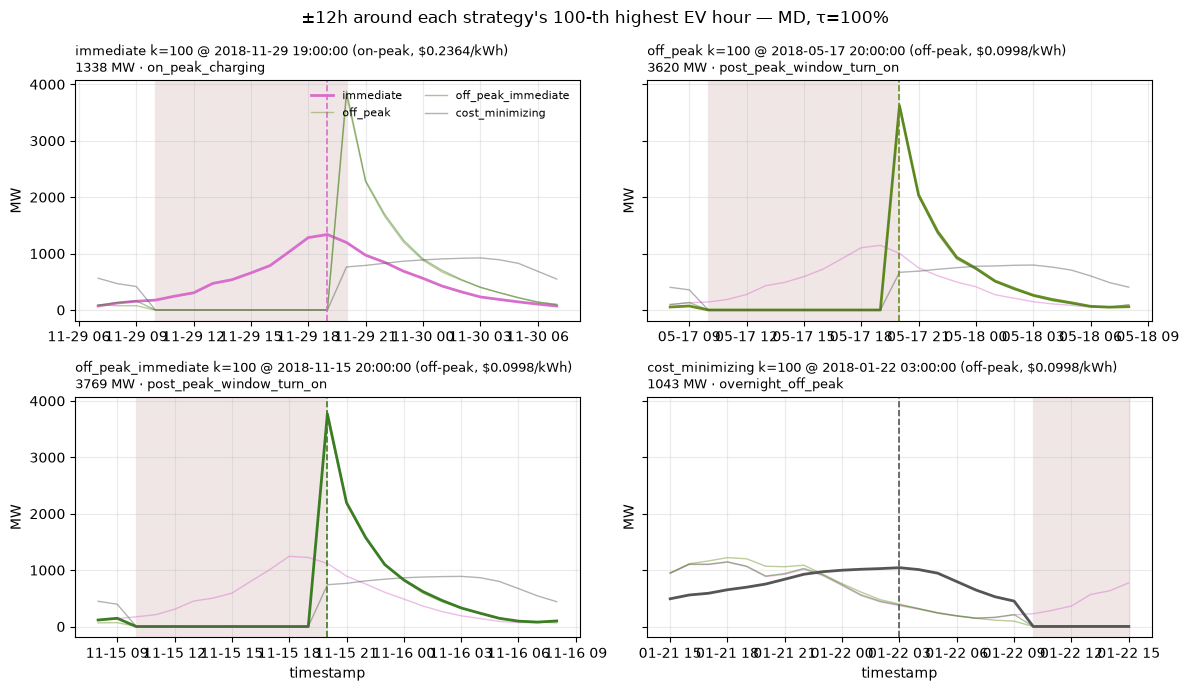


Daily fleet charge (MWh) around each strategy's k-th peak day:


strategy,k,peak_day,day,delta_days,fleet_charge_mwh,is_peak_day
str,i64,str,str,i64,f64,bool
"""immediate""",1,"""2018-01-18""","""2018-01-15""",-3,14384.2,false
"""immediate""",1,"""2018-01-18""","""2018-01-16""",-2,13818.3,false
"""immediate""",1,"""2018-01-18""","""2018-01-17""",-1,15580.7,false
"""immediate""",1,"""2018-01-18""","""2018-01-18""",0,17246.8,true
"""immediate""",1,"""2018-01-18""","""2018-01-19""",1,17231.1,false
…,…,…,…,…,…,…
"""cost_minimizing""",100,"""2018-01-22""","""2018-01-21""",-1,17988.7,false
"""cost_minimizing""",100,"""2018-01-22""","""2018-01-22""",0,12497.9,true
"""cost_minimizing""",100,"""2018-01-22""","""2018-01-23""",1,13383.8,false



Peak-day charge vs nearby days (stockpile ratio):


strategy,k,peak_day,peak_day_mwh,nearby_median_mwh,peak_over_nearby,mechanism
str,i64,str,f64,f64,f64,str
"""immediate""",1,"""2018-01-18""",17246.8,14660.35,1.18,"""on_peak_charging"""
"""immediate""",10,"""2018-01-18""",17246.8,14660.35,1.18,"""on_peak_charging"""
"""immediate""",50,"""2018-12-26""",16182.5,14245.8,1.14,"""on_peak_charging"""
"""immediate""",100,"""2018-11-29""",12719.5,12075.4,1.05,"""on_peak_charging"""
"""off_peak""",1,"""2018-12-24""",13499.2,14542.3,0.93,"""post_peak_window_turn_on"""
…,…,…,…,…,…,…
"""off_peak_immediate""",100,"""2018-11-15""",11688.7,11620.2,1.01,"""post_peak_window_turn_on"""
"""cost_minimizing""",1,"""2018-02-07""",13746.0,13479.25,1.02,"""overnight_off_peak"""
"""cost_minimizing""",10,"""2018-02-07""",13746.0,13479.25,1.02,"""overnight_off_peak"""


In [10]:
# --- EV-only peak-hour forensics at τ=100% for k=1, 10, 50, 100 ---
DIAG_TAU = 1.0
DIAG_WINDOW_H = 12
CHARGE_EPS = 1e-3  # kWh; treat below this as not charging
DIAG_Ks = K_PEAKS if "K_PEAKS" in globals() else (1, 10, 50, 100)

tou_kwargs = config.peak_window_kwargs()
is_off_peak = np.asarray(build_is_off_peak(hours_base, **tou_kwargs), dtype=bool)
hourly_prices = resolve_hourly_prices(config)
if hourly_prices is None:
    hourly_prices = np.full(hours_base.height, np.nan, dtype=np.float64)
else:
    hourly_prices = np.asarray(hourly_prices, dtype=np.float64)

ev_ids_100 = ev_ids_by_tau[float(DIAG_TAU)]
row_idx_100 = np.asarray(
    [bldg_id_to_row[b] for b in ev_ids_100 if b in bldg_id_to_row], dtype=np.int64
)
w_100 = weights[row_idx_100]


def _fleet_load_mw(charge_mat: np.ndarray) -> np.ndarray:
    return (w_100 @ charge_mat[row_idx_100]) / 1000.0


def _hour_context(hour_idx: int) -> dict:
    ts = timestamps[hour_idx]
    return {
        "timestamp": ts,
        "weekday": ts.strftime("%A"),
        "month": int(ts.month),
        "clock_hour": int(ts.hour),
        "is_off_peak": bool(is_off_peak[hour_idx]),
        "tou_label": "off-peak" if is_off_peak[hour_idx] else "on-peak",
        "price_usd_per_kwh": float(hourly_prices[hour_idx])
        if np.isfinite(hourly_prices[hour_idx])
        else None,
    }


def _mechanism_tag(ctx: dict) -> str:
    if ctx["tou_label"] == "on-peak":
        return "on_peak_charging"
    # Year-round summer window ends at hour 19 → first off-peak hour is 20
    if ctx["clock_hour"] in (20, 21) and ctx["tou_label"] == "off-peak":
        return "post_peak_window_turn_on"
    if ctx["clock_hour"] >= 22 or ctx["clock_hour"] <= 5:
        return "overnight_off_peak"
    return "other_off_peak"


loads_by_strategy: dict[str, np.ndarray] = {
    s: _fleet_load_mw(charge_by_strategy[s]) for s in CHARGING_STRATEGIES
}
# Descending hour ranks per strategy
order_by_strategy = {
    s: np.argsort(loads_by_strategy[s])[::-1] for s in CHARGING_STRATEGIES
}

kth_diag_rows = []
kth_idx_by_sk: dict[tuple[str, int], int] = {}
for strategy in CHARGING_STRATEGIES:
    load_mw = loads_by_strategy[strategy]
    order = order_by_strategy[strategy]
    for k in DIAG_Ks:
        peak_idx = int(order[k - 1])
        kth_idx_by_sk[(strategy, k)] = peak_idx
        ctx = _hour_context(peak_idx)
        charge_at = charge_by_strategy[strategy][row_idx_100, peak_idx]
        charging = charge_at > CHARGE_EPS
        n_charging = int(charging.sum())
        kth_diag_rows.append(
            {
                "strategy": strategy,
                "k": k,
                **{
                    key: ctx[key]
                    for key in (
                        "timestamp",
                        "weekday",
                        "month",
                        "clock_hour",
                        "tou_label",
                        "price_usd_per_kwh",
                    )
                },
                "mechanism": _mechanism_tag(ctx),
                "mw": float(load_mw[peak_idx]),
                "n_ev_charging": n_charging,
                "share_ev_charging": n_charging / max(len(row_idx_100), 1),
                "mean_charge_kwh_if_charging": float(charge_at[charging].mean())
                if n_charging
                else 0.0,
                "p95_charge_kwh_if_charging": float(np.quantile(charge_at[charging], 0.95))
                if n_charging
                else 0.0,
                "max_charge_kwh": float(charge_at.max()) if len(charge_at) else 0.0,
            }
        )

kth_diag_df = pl.DataFrame(kth_diag_rows)
print(f"EV-only k-th hour forensics @ τ={DIAG_TAU:.0%}  ({len(row_idx_100):,} EVs)")
if config.peak_clock_hours_summer is not None:
    print(
        f"TOU: BGE seasonal  summer peak hours={list(config.peak_clock_hours_summer)}  "
        f"winter={list(config.peak_clock_hours_winter)}  "
        f"summer_months={list(config.tou_summer_months)}"
    )
else:
    print(
        f"TOU: year-round peak hours={list(config.peak_clock_hours or [])}  "
        f"weekends_off_peak={config.tou_weekends_off_peak}  "
        f"holidays_off_peak={config.tou_holidays_off_peak}  "
        f"emergency_48h={bool(config.allow_emergency_peak_charging)}"
    )
display(kth_diag_df)

# Mechanism tags: are k=10 / 50 / 100 the same family as k=1?
print("\nMechanism tags by strategy × k:")
display(
    kth_diag_df.pivot(on="k", index="strategy", values="mechanism").sort("strategy")
)

# Cross-strategy MW at each (owner, k) peak hour
cross_rows = []
for strategy in CHARGING_STRATEGIES:
    for k in DIAG_Ks:
        i = kth_idx_by_sk[(strategy, k)]
        row = {
            "peak_owner": strategy,
            "k": k,
            "timestamp": timestamps[i],
            "mechanism": _mechanism_tag(_hour_context(i)),
            "tou_label": "off-peak" if is_off_peak[i] else "on-peak",
        }
        for s in CHARGING_STRATEGIES:
            row[f"{s}_mw"] = float(loads_by_strategy[s][i])
        cross_rows.append(row)
print("\nFleet EV load (MW) at each strategy's k-th peak hour:")
display(pl.DataFrame(cross_rows))

# ±12h profiles: one 2×2 figure per k
for k in DIAG_Ks:
    fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey=True)
    axes = axes.ravel()
    for ax, strategy in zip(axes, CHARGING_STRATEGIES):
        i = kth_idx_by_sk[(strategy, k)]
        lo = max(0, i - DIAG_WINDOW_H)
        hi = min(len(timestamps), i + DIAG_WINDOW_H + 1)
        xs = timestamps[lo:hi]
        for s in CHARGING_STRATEGIES:
            ax.plot(
                xs,
                loads_by_strategy[s][lo:hi],
                color=STRATEGY_COLORS[s],
                linewidth=2.0 if s == strategy else 1.0,
                alpha=1.0 if s == strategy else 0.45,
                label=s if strategy == CHARGING_STRATEGIES[0] else None,
            )
        for j in range(lo, hi):
            if not is_off_peak[j]:
                ax.axvspan(
                    timestamps[j],
                    timestamps[min(j + 1, hi - 1)],
                    color="#f0e6e6",
                    zorder=0,
                )
        ax.axvline(timestamps[i], color=STRATEGY_COLORS[strategy], linestyle="--", linewidth=1.2)
        ctx = _hour_context(i)
        price_s = (
            f", ${ctx['price_usd_per_kwh']:.4f}/kWh"
            if ctx["price_usd_per_kwh"] is not None
            else ""
        )
        ax.set_title(
            f"{strategy} k={k} @ {timestamps[i]} ({ctx['tou_label']}{price_s})\n"
            f"{loads_by_strategy[strategy][i]:.0f} MW · {_mechanism_tag(ctx)}",
            loc="left",
            fontsize=9,
        )
        ax.set_ylabel("MW")
        ax.grid(True, alpha=0.25)
    axes[0].legend(frameon=False, fontsize=8, ncols=2)
    axes[2].set_xlabel("timestamp")
    axes[3].set_xlabel("timestamp")
    fig.suptitle(
        f"±{DIAG_WINDOW_H}h around each strategy's {k}-th highest EV hour — "
        f"{STATE}, τ={DIAG_TAU:.0%}",
        fontsize=12,
    )
    fig.tight_layout()
    plt.show()

# Daily fleet charge energy on each k-th peak day (±3 days) — stockpiling check
from collections import defaultdict

day_hours: dict[tuple[int, int], list[int]] = defaultdict(list)
for j, t in enumerate(timestamps):
    day_hours[(t.month, t.day)].append(j)

print("\nDaily fleet charge (MWh) around each strategy's k-th peak day:")
daily_rows = []
for strategy in CHARGING_STRATEGIES:
    mat = charge_by_strategy[strategy]
    for k in DIAG_Ks:
        i = kth_idx_by_sk[(strategy, k)]
        peak_day = timestamps[i].date()
        for delta in range(-3, 4):
            d = peak_day.fromordinal(peak_day.toordinal() + delta)
            idx = day_hours.get((d.month, d.day), [])
            if not idx:
                continue
            mwh = float((mat[row_idx_100][:, idx] * w_100[:, None]).sum() / 1000.0)
            daily_rows.append(
                {
                    "strategy": strategy,
                    "k": k,
                    "peak_day": str(peak_day),
                    "day": str(d),
                    "delta_days": delta,
                    "fleet_charge_mwh": round(mwh, 1),
                    "is_peak_day": delta == 0,
                }
            )
daily_df = pl.DataFrame(daily_rows)
display(daily_df)

# Compact: peak-day MWh vs median of ±3 neighbors (excluding peak day)
print("\nPeak-day charge vs nearby days (stockpile ratio):")
ratio_rows = []
for strategy in CHARGING_STRATEGIES:
    for k in DIAG_Ks:
        sub = daily_df.filter((pl.col("strategy") == strategy) & (pl.col("k") == k))
        peak_mwh = float(sub.filter(pl.col("is_peak_day"))["fleet_charge_mwh"][0])
        neigh = sub.filter(~pl.col("is_peak_day"))["fleet_charge_mwh"]
        neigh_med = float(neigh.median()) if neigh.len() else float("nan")
        ratio_rows.append(
            {
                "strategy": strategy,
                "k": k,
                "peak_day": sub["peak_day"][0],
                "peak_day_mwh": peak_mwh,
                "nearby_median_mwh": neigh_med,
                "peak_over_nearby": round(peak_mwh / neigh_med, 2)
                if neigh_med and neigh_med > 0
                else None,
                "mechanism": kth_diag_df.filter(
                    (pl.col("strategy") == strategy) & (pl.col("k") == k)
                )["mechanism"][0],
            }
        )
display(pl.DataFrame(ratio_rows))


### Peak total residential demand (base + EV) vs adoption

ResStock upgrade=00 electricity (`out.electricity.total`, no EV end-use) for all MD buildings,
weight-weighted, plus modeled EV charging at each $\tau$. Peak is $\max_t(\mathrm{base}_t + \mathrm{EV}_t(\tau))$ —
not base peak + EV peak, since the hours may differ.

Base loads are AMY2018 clock hours joined onto the 2018 simulation calendar (same as
`ev_presentation.ipynb`); calendars match so there is no Feb 29 gap.


In [11]:
# ResStock base residential loads (AMY2018) — same buildings as the EV charge cache
LOAD_RELEASE = "res_2024_amy2018_2_sb"
PATH_LOADS_DIR = (
    Path("/ebs/data/nrel/resstock")
    / LOAD_RELEASE
    / "load_curve_hourly"
    / f"state={STATE}"
    / "upgrade=00"
)
ELEC_COL = "out.electricity.total.energy_consumption"
BASE_CACHE_NPY = CACHE_DIR / "base_residential_weighted_kwh_f32.npy"
FORCE_REBUILD_BASE_CACHE = False

n_hours = hours_base.height
ts_list = hours_base["timestamp"].to_list()
cal_to_idx: dict[tuple[int, int, int], int] = {
    (ts.month, ts.day, ts.hour): i for i, ts in enumerate(ts_list)
}

if BASE_CACHE_NPY.exists() and not FORCE_REBUILD_BASE_CACHE:
    base_load = np.load(BASE_CACHE_NPY).astype(np.float64)
    assert base_load.shape == (n_hours,)
    print(
        f"Loaded base residential cache: {BASE_CACHE_NPY} "
        f"({BASE_CACHE_NPY.stat().st_size / 1e6:.1f} MB)"
    )
else:
    print(
        f"Building weight-weighted base load from {PATH_LOADS_DIR} "
        f"({len(bldg_ids):,} buildings)…"
    )
    # All upgrade=00 files share the same AMY2018 hour grid — map once.
    sample_path = PATH_LOADS_DIR / f"{int(bldg_ids[0])}-0.parquet"
    sample_ts = pl.read_parquet(sample_path, columns=["timestamp"])["timestamp"]
    amy_months = sample_ts.dt.month().to_numpy()
    amy_days = sample_ts.dt.day().to_numpy()
    amy_hours = sample_ts.dt.hour().to_numpy()
    n_amy = sample_ts.len()
    amy_to_hb = np.full(n_amy, -1, dtype=np.int32)
    for j in range(n_amy):
        amy_to_hb[j] = cal_to_idx.get(
            (int(amy_months[j]), int(amy_days[j]), int(amy_hours[j])), -1
        )
    matched = amy_to_hb >= 0
    hb_idx = amy_to_hb[matched]
    amy_idx = np.nonzero(matched)[0]

    base_load = np.zeros(n_hours, dtype=np.float64)
    n_missing = 0
    for i, (bid, w) in enumerate(zip(bldg_ids.tolist(), weights.tolist())):
        path = PATH_LOADS_DIR / f"{int(bid)}-0.parquet"
        if not path.exists():
            n_missing += 1
            continue
        elec = (
            pl.read_parquet(path, columns=[ELEC_COL])[ELEC_COL]
            .to_numpy()
            .astype(np.float64)
        )
        if elec.shape[0] != n_amy:
            raise RuntimeError(f"{path} has {elec.shape[0]} hours, expected {n_amy}")
        base_load[hb_idx] += w * elec[amy_idx]
        if (i + 1) % 1000 == 0 or i + 1 == len(bldg_ids):
            print(f"  {i + 1:,}/{len(bldg_ids):,} buildings")

    # Hours with no AMY match → NaN so they are excluded from nanmax
    covered = np.zeros(n_hours, dtype=bool)
    covered[hb_idx] = True
    base_load[~covered] = np.nan

    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    np.save(BASE_CACHE_NPY, base_load.astype(np.float32))
    print(
        f"Wrote {BASE_CACHE_NPY}  missing_files={n_missing}  "
        f"finite_hours={np.isfinite(base_load).sum():,}"
    )

print(
    f"Base peak={np.nanmax(base_load)/1000:.2f} MW  "
    f"mean={np.nanmean(base_load)/1000:.2f} MW  "
    f"(weight-weighted, {np.isfinite(base_load).sum():,} hours)"
)


Loaded base residential cache: /ebs/home/lily_switch_box/buildstock-fetch/utils/EVs/ev_data/outputs/MD_res_2024_tmy3_2/adoption_peak_sweep/base_residential_weighted_kwh_f32.npy (0.0 MB)
Base peak=11962.07 MW  mean=3721.43 MW  (weight-weighted, 8,760 hours)


strategy,adoption_rate,peak_total_mw,peak_base_at_total_peak_mw,peak_ev_at_total_peak_mw,ev_only_peak_mw,peak_timestamp,base_only_peak_mw
str,f64,f64,f64,f64,f64,datetime[μs],f64
"""Immediate""",0.0,11962.068,11962.068,0.0,0.0,2018-01-07 07:00:00,11962.068
"""Immediate""",0.05,11965.889132,11962.068,3.821132,98.743741,2018-01-07 07:00:00,11962.068
"""Immediate""",0.1,11970.789078,11962.068,8.721078,187.518101,2018-01-07 07:00:00,11962.068
"""Immediate""",0.15,11976.991393,11962.068,14.923393,273.450246,2018-01-07 07:00:00,11962.068
"""Immediate""",0.2,11981.486095,11962.068,19.418095,371.552147,2018-01-07 07:00:00,11962.068
…,…,…,…,…,…,…,…
"""TOU Immediate""",0.8,14179.520622,10765.614,3413.906622,3744.368554,2018-01-05 20:00:00,11962.068
"""TOU Immediate""",0.85,14331.547772,10765.614,3565.933772,3908.128293,2018-01-05 20:00:00,11962.068
"""TOU Immediate""",0.9,14487.963337,10765.614,3722.349337,4076.171362,2018-01-05 20:00:00,11962.068


adoption_rate,Immediate,TOU Immediate
f64,f64,f64
0.0,11962.068,11962.068
0.05,11965.889132,11966.547957
0.1,11970.789078,11971.851585
0.15,11976.991393,11979.367361
0.2,11981.486095,11983.862063
…,…,…
0.8,12056.663161,14179.520622
0.85,12075.031678,14331.547772
0.9,12144.557638,14487.963337


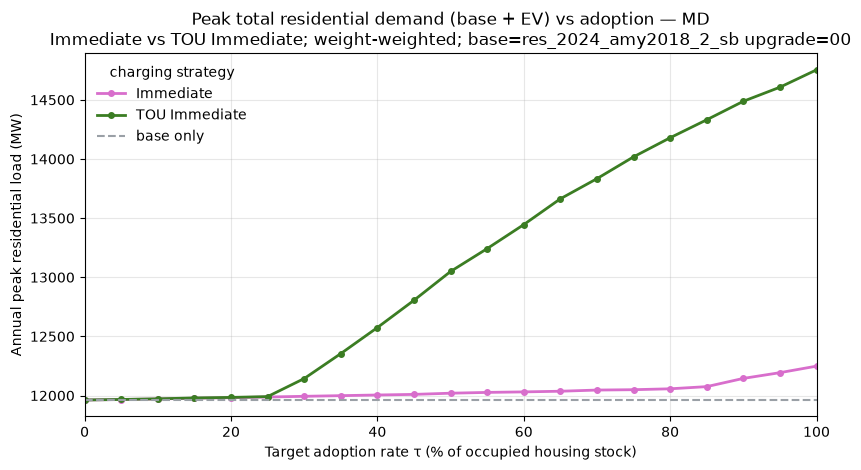

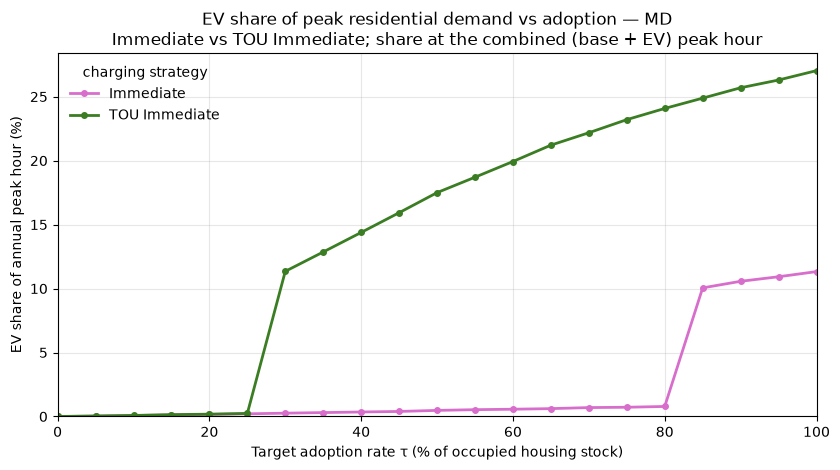

[TOU Immediate] τ=0%: total peak=11962.1 MW (base=11962.1 + EV=0.0, EV share=0.0%) at 2018-01-07 07:00:00
[TOU Immediate] τ=25%: total peak=11990.7 MW (base=11962.1 + EV=28.6, EV share=0.2%) at 2018-01-07 07:00:00
[TOU Immediate] τ=50%: total peak=13048.8 MW (base=10765.6 + EV=2283.1, EV share=17.5%) at 2018-01-05 20:00:00
[TOU Immediate] τ=75%: total peak=14018.0 MW (base=10765.6 + EV=3252.4, EV share=23.2%) at 2018-01-05 20:00:00
[TOU Immediate] τ=100%: total peak=14753.9 MW (base=10765.6 + EV=3988.2, EV share=27.0%) at 2018-01-05 20:00:00


In [12]:
# Peak of (base + EV) at each τ × strategy — Immediate vs TOU Immediate
PLOT_STRATEGIES = ["immediate", "off_peak_immediate"]
PLOT_LABELS = {
    "immediate": "Immediate",
    "off_peak_immediate": "TOU Immediate",
}

total_peak_rows = []
valid = np.isfinite(base_load)

for strategy in PLOT_STRATEGIES:
    charge_mat_s = charge_by_strategy[strategy]
    for tau in ADOPTION_RATES:
        ev_ids = ev_ids_by_tau[float(tau)]
        rows = [bldg_id_to_row[b] for b in ev_ids if b in bldg_id_to_row]
        if not rows:
            ev_load = np.zeros(n_hours, dtype=np.float64)
        else:
            idx = np.asarray(rows, dtype=np.int64)
            ev_load = weights[idx] @ charge_mat_s[idx]

        total = base_load + ev_load  # NaN where base missing
        peak_idx = int(np.nanargmax(total))
        peak_total = float(total[peak_idx])
        peak_base_at = float(base_load[peak_idx]) if valid[peak_idx] else float("nan")
        peak_ev_at = float(ev_load[peak_idx])

        ev_peak_idx = int(np.argmax(ev_load)) if rows else 0
        ev_peak = float(ev_load[ev_peak_idx]) if rows else 0.0

        total_peak_rows.append({
            "strategy": strategy,
            "adoption_rate": float(tau),
            "peak_total_mw": peak_total / 1000.0,
            "peak_base_at_total_peak_mw": peak_base_at / 1000.0,
            "peak_ev_at_total_peak_mw": peak_ev_at / 1000.0,
            "ev_only_peak_mw": ev_peak / 1000.0,
            "peak_timestamp": ts_list[peak_idx],
            "base_only_peak_mw": float(np.nanmax(base_load)) / 1000.0,
        })

total_peak_df = pl.DataFrame(total_peak_rows)
display(
    total_peak_df.with_columns(pl.col("strategy").replace(PLOT_LABELS))
)
display(
    total_peak_df.with_columns(pl.col("strategy").replace(PLOT_LABELS))
    .pivot(
        on="strategy",
        index="adoption_rate",
        values="peak_total_mw",
    )
    .sort("adoption_rate")
)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
base_only = float(total_peak_df["base_only_peak_mw"][0])
for strategy in PLOT_STRATEGIES:
    sub = total_peak_df.filter(pl.col("strategy") == strategy).sort("adoption_rate")
    ax.plot(
        sub["adoption_rate"].to_numpy() * 100,
        sub["peak_total_mw"].to_numpy(),
        color=STRATEGY_COLORS[strategy],
        marker="o",
        linewidth=2,
        markersize=4,
        label=PLOT_LABELS[strategy],
    )
ax.axhline(
    base_only,
    color="#9AA0A6",
    linestyle="--",
    linewidth=1.5,
    label="base only",
)
ax.set_xlabel("Target adoption rate τ (% of occupied housing stock)")
ax.set_ylabel("Annual peak residential load (MW)")
ax.set_title(
    f"Peak total residential demand (base + EV) vs adoption — {STATE}\n"
    f"Immediate vs TOU Immediate; weight-weighted; base={LOAD_RELEASE} upgrade=00"
)
ax.set_xlim(0, 100)
ax.grid(True, alpha=0.3)
ax.legend(frameon=False, title="charging strategy")
fig.tight_layout()
plt.show()

# EV share of the combined (base + EV) peak hour
total_peak_df = total_peak_df.with_columns(
    pl.when(pl.col("peak_total_mw") > 0)
    .then(pl.col("peak_ev_at_total_peak_mw") / pl.col("peak_total_mw"))
    .otherwise(0.0)
    .alias("ev_share_of_peak")
)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
for strategy in PLOT_STRATEGIES:
    sub = total_peak_df.filter(pl.col("strategy") == strategy).sort("adoption_rate")
    ax.plot(
        sub["adoption_rate"].to_numpy() * 100,
        sub["ev_share_of_peak"].to_numpy() * 100,
        color=STRATEGY_COLORS[strategy],
        marker="o",
        linewidth=2,
        markersize=4,
        label=PLOT_LABELS[strategy],
    )
ax.set_xlabel("Target adoption rate τ (% of occupied housing stock)")
ax.set_ylabel("EV share of annual peak hour (%)")
ax.set_title(
    f"EV share of peak residential demand vs adoption — {STATE}\n"
    f"Immediate vs TOU Immediate; share at the combined (base + EV) peak hour"
)
ax.set_xlim(0, 100)
ax.set_ylim(0, None)
ax.grid(True, alpha=0.3)
ax.legend(frameon=False, title="charging strategy")
fig.tight_layout()
plt.show()

# How much of the combined peak hour is EV at a few milestones (TOU Immediate)
default_s = "off_peak_immediate"
for tau in (0.0, 0.25, 0.50, 0.75, 1.00):
    row = total_peak_df.filter(
        (pl.col("strategy") == default_s) & (pl.col("adoption_rate") == tau)
    )
    if row.height:
        print(
            f"[{PLOT_LABELS[default_s]}] τ={tau:.0%}: total peak={row['peak_total_mw'][0]:.1f} MW "
            f"(base={row['peak_base_at_total_peak_mw'][0]:.1f} + "
            f"EV={row['peak_ev_at_total_peak_mw'][0]:.1f}, "
            f"EV share={row['ev_share_of_peak'][0]:.1%}) at {row['peak_timestamp'][0]}"
        )


### Robust peaks — $k$-th highest hour (base + EV)

Same $k \in \{1, 10, 50, 100\}$ check on $\mathrm{base}_t + \mathrm{EV}_t(\tau)$. Hours where
base is missing are excluded, matching the annual-max logic.

Below the MW curves, a companion 4-panel figure shows **EV share of that combined peak**: $100 \times \mathrm{EV}/(\mathrm{base}+\mathrm{EV})$ at the same $k$-th highest hour.


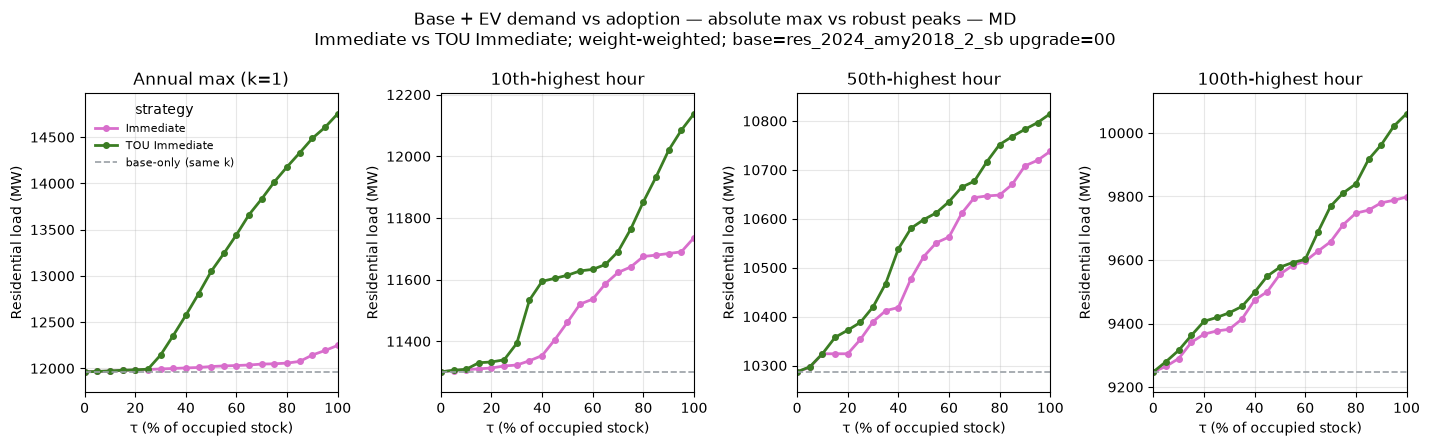

τ=100% k-th highest base+EV timestamps:


strategy,k,kth_total_mw,base_at_kth_mw,ev_at_kth_mw,kth_timestamp
str,i64,f64,f64,f64,datetime[μs]
"""Immediate""",1,12248.34599,10861.223,1387.12299,2018-01-04 19:00:00
"""Immediate""",10,11736.05433,10698.878,1037.17633,2018-01-04 21:00:00
"""Immediate""",50,10738.007632,10060.186,677.821632,2018-01-04 23:00:00
"""Immediate""",100,9798.322908,9556.69,241.632908,2018-01-04 11:00:00
"""TOU Immediate""",1,14753.861367,10765.614,3988.247367,2018-01-05 20:00:00
"""TOU Immediate""",10,12138.205546,8231.253,3906.952546,2018-02-02 20:00:00
"""TOU Immediate""",50,10814.960613,10591.165,223.795613,2018-01-05 05:00:00
"""TOU Immediate""",100,10060.62265,9121.77,938.85265,2018-01-02 00:00:00


τ=100% base+EV load (MW) by k × strategy:


k,Immediate,TOU Immediate
i64,f64,f64
1,12248.34599,14753.861367
10,11736.05433,12138.205546
50,10738.007632,10814.960613
100,9798.322908,10060.62265


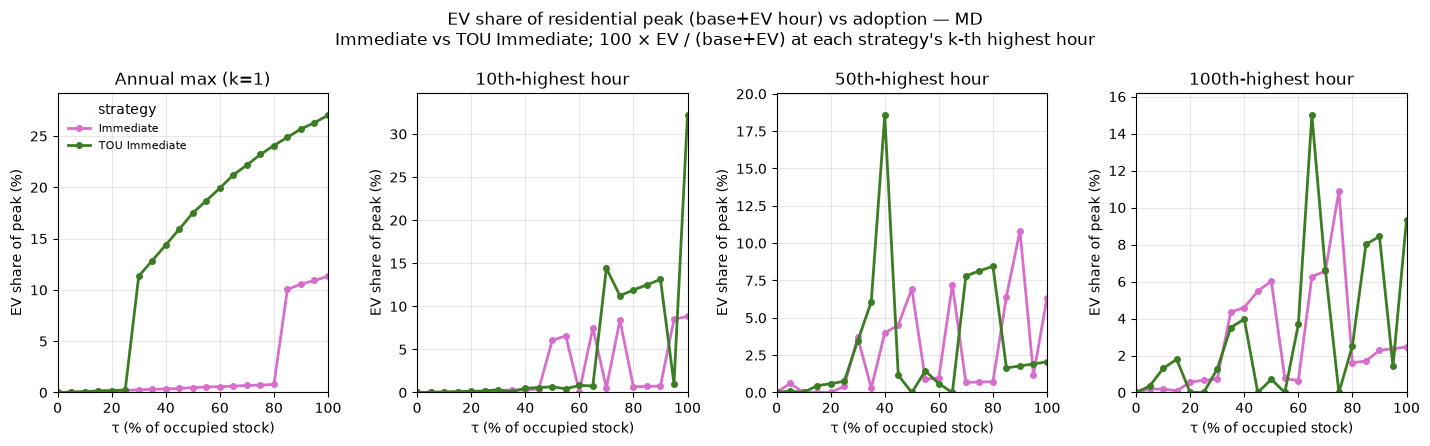

τ=100% EV share (%) at k-th highest base+EV hour:


k,Immediate,TOU Immediate
i64,f64,f64
1,11.324982,27.031889
10,8.837522,32.187233
50,6.312359,2.069315
100,2.466064,9.331954


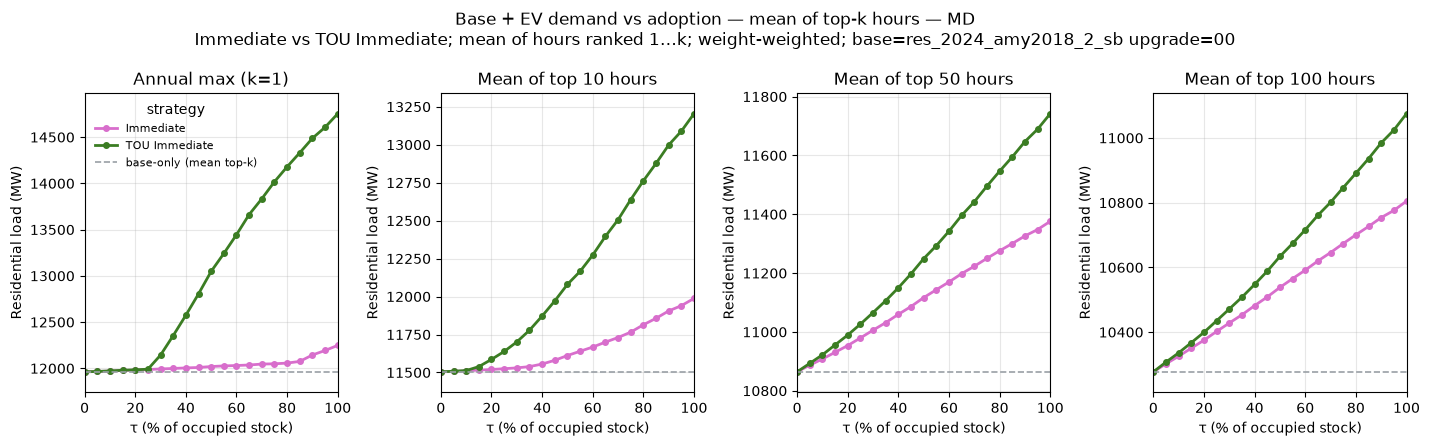

τ=100% mean of top-k base+EV load (MW) by k × strategy:


k,Immediate,TOU Immediate
i64,f64,f64
1,12248.34599,14753.861367
10,11987.760586,13204.361035
50,11376.067042,11742.090159
100,10804.681002,11074.954809


In [13]:
# Base + EV: k-th highest combined hourly load vs adoption
# Presentation subset: Immediate vs TOU Immediate only
PLOT_STRATEGIES = ["immediate", "off_peak_immediate"]
PLOT_LABELS = {
    "immediate": "Immediate",
    "off_peak_immediate": "TOU Immediate",
}

valid = np.isfinite(base_load)
kth_total_rows = []
topk_mean_rows = []

for strategy in PLOT_STRATEGIES:
    charge_mat_s = charge_by_strategy[strategy]
    for tau in ADOPTION_RATES:
        ev_ids = ev_ids_by_tau[float(tau)]
        rows = [bldg_id_to_row[b] for b in ev_ids if b in bldg_id_to_row]
        if not rows:
            ev_load = np.zeros(n_hours, dtype=np.float64)
        else:
            idx = np.asarray(rows, dtype=np.int64)
            ev_load = weights[idx] @ charge_mat_s[idx]

        total = base_load + ev_load
        # Rank only finite hours (same exclusion as nanargmax)
        finite_idx = np.flatnonzero(valid)
        finite_vals = total[finite_idx]
        order_local = np.argsort(finite_vals)[::-1]
        for k in K_PEAKS:
            hour_idx = int(finite_idx[order_local[k - 1]])
            kth_total_rows.append(
                {
                    "strategy": strategy,
                    "adoption_rate": float(tau),
                    "k": k,
                    "kth_total_mw": float(total[hour_idx]) / 1000.0,
                    "base_at_kth_mw": float(base_load[hour_idx]) / 1000.0,
                    "ev_at_kth_mw": float(ev_load[hour_idx]) / 1000.0,
                    "kth_hour_index": hour_idx,
                    "kth_timestamp": ts_list[hour_idx],
                }
            )
            # Mean over the top-k combined hours (k=1 ≡ annual max)
            top_idx = finite_idx[order_local[:k]]
            topk_mean_rows.append(
                {
                    "strategy": strategy,
                    "adoption_rate": float(tau),
                    "k": k,
                    "topk_mean_total_mw": float(total[top_idx].mean()) / 1000.0,
                    "topk_mean_base_mw": float(base_load[top_idx].mean()) / 1000.0,
                    "topk_mean_ev_mw": float(ev_load[top_idx].mean()) / 1000.0,
                }
            )

kth_total_df = pl.DataFrame(kth_total_rows)
topk_mean_df = pl.DataFrame(topk_mean_rows)

fig, axes = plt.subplots(1, len(K_PEAKS), figsize=(3.6 * len(K_PEAKS), 4.5), sharey=False)
# Reference per panel: k-th highest BASE-ONLY hour (apples-to-apples with the
# k-th highest base+EV hour; the base annual max would sit above the k=50/100 curves).
base_sorted_desc = np.sort(base_load[np.isfinite(base_load)])[::-1] / 1000.0
for ax, k in zip(axes, K_PEAKS):
    base_kth = float(base_sorted_desc[k - 1])
    y_vals = [base_kth]
    for strategy in PLOT_STRATEGIES:
        sub = kth_total_df.filter(
            (pl.col("strategy") == strategy) & (pl.col("k") == k)
        ).sort("adoption_rate")
        y = sub["kth_total_mw"].to_numpy()
        y_vals.append(float(np.nanmin(y)))
        y_vals.append(float(np.nanmax(y)))
        ax.plot(
            sub["adoption_rate"].to_numpy() * 100,
            y,
            color=STRATEGY_COLORS[strategy],
            marker="o",
            linewidth=2,
            markersize=4,
            label=PLOT_LABELS[strategy],
        )
    ax.axhline(
        base_kth,
        color="#9AA0A6",
        linestyle="--",
        linewidth=1.2,
        label="base-only (same k)" if k == K_PEAKS[0] else None,
    )
    # Zoom to this panel's range — shared 0→12 GW scale hides EV increments.
    ymin, ymax = min(y_vals), max(y_vals)
    pad = max((ymax - ymin) * 0.08, 5.0)
    ax.set_ylim(ymin - pad, ymax + pad)
    title = "Annual max (k=1)" if k == 1 else f"{k}th-highest hour"
    ax.set_title(title)
    ax.set_xlabel("τ (% of occupied stock)")
    ax.set_ylabel("Residential load (MW)")
    ax.set_xlim(0, 100)
    ax.grid(True, alpha=0.3)

axes[0].legend(frameon=False, fontsize=8, title="strategy")
fig.suptitle(
    f"Base + EV demand vs adoption — absolute max vs robust peaks — {STATE}\n"
    f"Immediate vs TOU Immediate; weight-weighted; base={LOAD_RELEASE} upgrade=00",
    fontsize=12,
)
fig.tight_layout()
plt.show()

print("τ=100% k-th highest base+EV timestamps:")
display(
    kth_total_df.filter(pl.col("adoption_rate") == 1.0)
    .with_columns(pl.col("strategy").replace(PLOT_LABELS))
    .select(
        "strategy", "k", "kth_total_mw", "base_at_kth_mw", "ev_at_kth_mw", "kth_timestamp"
    )
    .sort("strategy", "k")
)

print("τ=100% base+EV load (MW) by k × strategy:")
display(
    kth_total_df.filter(pl.col("adoption_rate") == 1.0)
    .with_columns(pl.col("strategy").replace(PLOT_LABELS))
    .pivot(on="strategy", index="k", values="kth_total_mw")
    .sort("k")
)


# --- Companion: EV % of demand at the same k-th highest base+EV hours ---
kth_share_df = kth_total_df.with_columns(
    (
        pl.when(pl.col("kth_total_mw") > 0)
        .then(100.0 * pl.col("ev_at_kth_mw") / pl.col("kth_total_mw"))
        .otherwise(0.0)
    ).alias("ev_share_pct")
)

fig, axes = plt.subplots(1, len(K_PEAKS), figsize=(3.6 * len(K_PEAKS), 4.5), sharey=False)
for ax, k in zip(axes, K_PEAKS):
    y_vals = []
    for strategy in PLOT_STRATEGIES:
        sub = kth_share_df.filter(
            (pl.col("strategy") == strategy) & (pl.col("k") == k)
        ).sort("adoption_rate")
        y = sub["ev_share_pct"].to_numpy()
        y_vals.extend([float(np.nanmin(y)), float(np.nanmax(y))])
        ax.plot(
            sub["adoption_rate"].to_numpy() * 100,
            y,
            color=STRATEGY_COLORS[strategy],
            marker="o",
            linewidth=2,
            markersize=4,
            label=PLOT_LABELS[strategy],
        )
    ymin, ymax = (min(y_vals), max(y_vals)) if y_vals else (0.0, 1.0)
    pad = max((ymax - ymin) * 0.08, 0.5)
    ax.set_ylim(max(0.0, ymin - pad), min(100.0, ymax + pad))
    title = "Annual max (k=1)" if k == 1 else f"{k}th-highest hour"
    ax.set_title(title)
    ax.set_xlabel("τ (% of occupied stock)")
    ax.set_ylabel("EV share of peak (%)")
    ax.set_xlim(0, 100)
    ax.grid(True, alpha=0.3)

axes[0].legend(frameon=False, fontsize=8, title="strategy")
fig.suptitle(
    f"EV share of residential peak (base+EV hour) vs adoption — {STATE}\n"
    f"Immediate vs TOU Immediate; 100 × EV / (base+EV) at each strategy's k-th highest hour",
    fontsize=12,
)
fig.tight_layout()
plt.show()

print("τ=100% EV share (%) at k-th highest base+EV hour:")
display(
    kth_share_df.filter(pl.col("adoption_rate") == 1.0)
    .with_columns(pl.col("strategy").replace(PLOT_LABELS))
    .pivot(on="strategy", index="k", values="ev_share_pct")
    .sort("k")
)


# --- Companion: mean of top-k combined hours (avg of hours ranked 1..k) ---
fig, axes = plt.subplots(1, len(K_PEAKS), figsize=(3.6 * len(K_PEAKS), 4.5), sharey=False)
# Base-only reference: mean of the top-k base hours (same ranking on base alone).
base_topk_mean = {
    k: float(base_sorted_desc[:k].mean()) for k in K_PEAKS
}
for ax, k in zip(axes, K_PEAKS):
    base_ref = base_topk_mean[k]
    y_vals = [base_ref]
    for strategy in PLOT_STRATEGIES:
        sub = topk_mean_df.filter(
            (pl.col("strategy") == strategy) & (pl.col("k") == k)
        ).sort("adoption_rate")
        y = sub["topk_mean_total_mw"].to_numpy()
        y_vals.append(float(np.nanmin(y)))
        y_vals.append(float(np.nanmax(y)))
        ax.plot(
            sub["adoption_rate"].to_numpy() * 100,
            y,
            color=STRATEGY_COLORS[strategy],
            marker="o",
            linewidth=2,
            markersize=4,
            label=PLOT_LABELS[strategy],
        )
    ax.axhline(
        base_ref,
        color="#9AA0A6",
        linestyle="--",
        linewidth=1.2,
        label="base-only (mean top-k)" if k == K_PEAKS[0] else None,
    )
    ymin, ymax = min(y_vals), max(y_vals)
    pad = max((ymax - ymin) * 0.08, 5.0)
    ax.set_ylim(ymin - pad, ymax + pad)
    title = "Annual max (k=1)" if k == 1 else f"Mean of top {k} hours"
    ax.set_title(title)
    ax.set_xlabel("τ (% of occupied stock)")
    ax.set_ylabel("Residential load (MW)")
    ax.set_xlim(0, 100)
    ax.grid(True, alpha=0.3)

axes[0].legend(frameon=False, fontsize=8, title="strategy")
fig.suptitle(
    f"Base + EV demand vs adoption — mean of top-k hours — {STATE}\n"
    f"Immediate vs TOU Immediate; mean of hours ranked 1…k; weight-weighted; "
    f"base={LOAD_RELEASE} upgrade=00",
    fontsize=12,
)
fig.tight_layout()
plt.show()

print("τ=100% mean of top-k base+EV load (MW) by k × strategy:")
display(
    topk_mean_df.filter(pl.col("adoption_rate") == 1.0)
    .with_columns(pl.col("strategy").replace(PLOT_LABELS))
    .pivot(on="strategy", index="k", values="topk_mean_total_mw")
    .sort("k")
)


### EV share at EV-only peak hours

Companion to the EV-only $k$-th highest MW curves: at those same hours (when EV
charging alone peaks), what fraction of **total residential** demand is EV?

$$
\mathrm{EV\ share}(\tau,k) = 100 \times \frac{\mathrm{EV}_{t^*}}{\mathrm{base}_{t^*} + \mathrm{EV}_{t^*}}
$$

where $t^*$ is the hour of the $k$-th highest EV-only load. Overnight EV peaks can
show high shares even when absolute combined demand is modest.


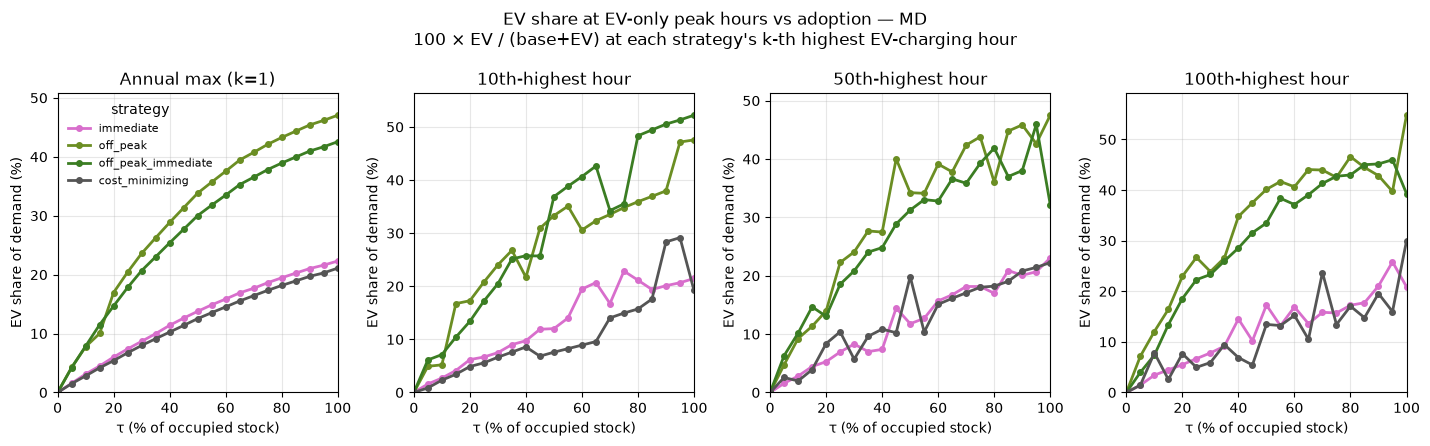

τ=100% EV share (%) at EV-only k-th peak hour:


strategy,k,ev_share_pct,ev_mw,base_mw,kth_timestamp
str,i64,f64,f64,f64,datetime[μs]
"""cost_minimizing""",1,21.102343,1207.442757,4514.3995,2018-02-07 03:00:00
"""cost_minimizing""",10,19.221615,1170.184148,4917.6715,2018-02-07 00:00:00
"""cost_minimizing""",50,22.263499,1098.303863,3834.90025,2018-02-14 01:00:00
"""cost_minimizing""",100,29.938082,1043.437854,2441.88175,2018-01-22 03:00:00
"""immediate""",1,22.316337,1667.839973,5805.788,2018-01-18 19:00:00
…,…,…,…,…,…
"""off_peak""",100,54.801616,3620.296003,2985.88875,2018-05-17 20:00:00
"""off_peak_immediate""",1,42.559237,4351.021074,5872.426,2018-01-18 20:00:00
"""off_peak_immediate""",10,52.203296,4150.085855,3799.76825,2018-01-22 20:00:00


k,immediate,off_peak,off_peak_immediate,cost_minimizing
i64,f64,f64,f64,f64
1,22.316337,47.058647,42.559237,21.102343
10,21.464361,47.553377,52.203296,19.221615
50,23.054423,47.509526,32.187233,22.263499
100,20.893112,54.801616,39.326537,29.938082


In [14]:
# EV share of (base+EV) at the hours of the EV-only k-th peaks (from kth_df)
assert "base_load" in globals() and "kth_df" in globals(), (
    "Need base_load and kth_df — run the base-load cell and EV-only robust-peak cell first."
)

ev_only_share_rows = []
for strategy in CHARGING_STRATEGIES:
    charge_mat_s = charge_by_strategy[strategy]
    for tau in ADOPTION_RATES:
        ev_ids = ev_ids_by_tau[float(tau)]
        rows = [bldg_id_to_row[b] for b in ev_ids if b in bldg_id_to_row]
        sub_k = kth_df.filter(
            (pl.col("strategy") == strategy) & (pl.col("adoption_rate") == float(tau))
        )
        for row in sub_k.iter_rows(named=True):
            hour_idx = int(row["kth_hour_index"])
            ev_mw = float(row["kth_charge_mw"])
            base_mw = (
                float(base_load[hour_idx]) / 1000.0
                if np.isfinite(base_load[hour_idx])
                else float("nan")
            )
            total_mw = base_mw + ev_mw if np.isfinite(base_mw) else float("nan")
            share = (
                100.0 * ev_mw / total_mw
                if np.isfinite(total_mw) and total_mw > 0
                else float("nan")
            )
            ev_only_share_rows.append(
                {
                    "strategy": strategy,
                    "adoption_rate": float(tau),
                    "k": int(row["k"]),
                    "ev_mw": ev_mw,
                    "base_mw": base_mw,
                    "total_mw": total_mw,
                    "ev_share_pct": share,
                    "kth_timestamp": row["kth_timestamp"],
                }
            )

ev_only_share_df = pl.DataFrame(ev_only_share_rows)

fig, axes = plt.subplots(1, len(K_PEAKS), figsize=(3.6 * len(K_PEAKS), 4.5), sharey=False)
for ax, k in zip(axes, K_PEAKS):
    y_vals = []
    for strategy in CHARGING_STRATEGIES:
        sub = ev_only_share_df.filter(
            (pl.col("strategy") == strategy) & (pl.col("k") == k)
        ).sort("adoption_rate")
        y = sub["ev_share_pct"].to_numpy()
        finite = y[np.isfinite(y)]
        if finite.size:
            y_vals.extend([float(finite.min()), float(finite.max())])
        ax.plot(
            sub["adoption_rate"].to_numpy() * 100,
            y,
            color=STRATEGY_COLORS[strategy],
            marker="o",
            linewidth=2,
            markersize=4,
            label=STRATEGY_LABELS[strategy],
        )
    if y_vals:
        ymin, ymax = min(y_vals), max(y_vals)
        pad = max((ymax - ymin) * 0.08, 0.5)
        ax.set_ylim(max(0.0, ymin - pad), min(100.0, ymax + pad))
    title = "Annual max (k=1)" if k == 1 else f"{k}th-highest hour"
    ax.set_title(title)
    ax.set_xlabel("τ (% of occupied stock)")
    ax.set_ylabel("EV share of demand (%)")
    ax.set_xlim(0, 100)
    ax.grid(True, alpha=0.3)

axes[0].legend(frameon=False, fontsize=8, title="strategy")
fig.suptitle(
    f"EV share at EV-only peak hours vs adoption — {STATE}\n"
    f"100 × EV / (base+EV) at each strategy's k-th highest EV-charging hour",
    fontsize=12,
)
fig.tight_layout()
plt.show()

print("τ=100% EV share (%) at EV-only k-th peak hour:")
display(
    ev_only_share_df.filter(pl.col("adoption_rate") == 1.0)
    .select("strategy", "k", "ev_share_pct", "ev_mw", "base_mw", "kth_timestamp")
    .sort("strategy", "k")
)
display(
    ev_only_share_df.filter(pl.col("adoption_rate") == 1.0)
    .pivot(on="strategy", index="k", values="ev_share_pct")
    .sort("k")
)


### Peak-hour diagnosis (base + EV) — $k \in \{1, 10, 50, 100\}$

Same forensics for the **$k$-th highest** combined hour $\mathrm{base}_t + \mathrm{EV}_t$
at $\tau=100\%$: does the system peak stay on the winter morning base peak, flip to an
evening EV pile-up, or sit on the post-peak / overnight off-peak turn-on?


Combined (base+EV) k-th hour forensics @ τ=100%


strategy,k,timestamp,weekday,clock_hour,tou_label,price_usd_per_kwh,mechanism,peak_total_mw,base_at_peak_mw,ev_at_peak_mw,ev_share_of_peak,same_hour_as_base_only_peak
str,i64,datetime[μs],str,i64,str,f64,str,f64,f64,f64,f64,bool
"""immediate""",1,2018-01-04 19:00:00,"""Thursday""",19,"""on-peak""",0.23636,"""on_peak_charging""",12248.34599,10861.223,1387.12299,0.11325,false
"""immediate""",10,2018-01-04 21:00:00,"""Thursday""",21,"""off-peak""",0.09981,"""post_peak_window_turn_on""",11736.05433,10698.878,1037.17633,0.088375,false
"""immediate""",50,2018-01-04 23:00:00,"""Thursday""",23,"""off-peak""",0.09981,"""overnight_off_peak""",10738.007632,10060.186,677.821632,0.063124,false
"""immediate""",100,2018-01-04 11:00:00,"""Thursday""",11,"""on-peak""",0.23636,"""on_peak_charging""",9798.322908,9556.69,241.632908,0.024661,false
"""off_peak""",1,2018-01-17 20:00:00,"""Wednesday""",20,"""off-peak""",0.09981,"""post_peak_window_turn_on""",12091.765615,8581.729,3510.036615,0.290283,false
…,…,…,…,…,…,…,…,…,…,…,…,…
"""off_peak_immediate""",100,2018-01-02 00:00:00,"""Tuesday""",0,"""off-peak""",0.09981,"""overnight_off_peak""",10060.62265,9121.77,938.85265,0.09332,false
"""cost_minimizing""",1,2018-01-07 07:00:00,"""Sunday""",7,"""off-peak""",0.09981,"""other_off_peak""",12545.96764,11962.068,583.89964,0.046541,true
"""cost_minimizing""",10,2018-01-05 08:00:00,"""Friday""",8,"""off-peak""",0.09981,"""other_off_peak""",11668.306957,11357.145,311.161957,0.026667,false



Mechanism tags by strategy × k (base+EV):


strategy,1,10,50,100
str,str,str,str,str
"""cost_minimizing""","""other_off_peak""","""other_off_peak""","""other_off_peak""","""other_off_peak"""
"""immediate""","""on_peak_charging""","""post_peak_window_turn_on""","""overnight_off_peak""","""on_peak_charging"""
"""off_peak""","""post_peak_window_turn_on""","""other_off_peak""","""on_peak_charging""","""post_peak_window_turn_on"""
"""off_peak_immediate""","""post_peak_window_turn_on""","""post_peak_window_turn_on""","""overnight_off_peak""","""overnight_off_peak"""


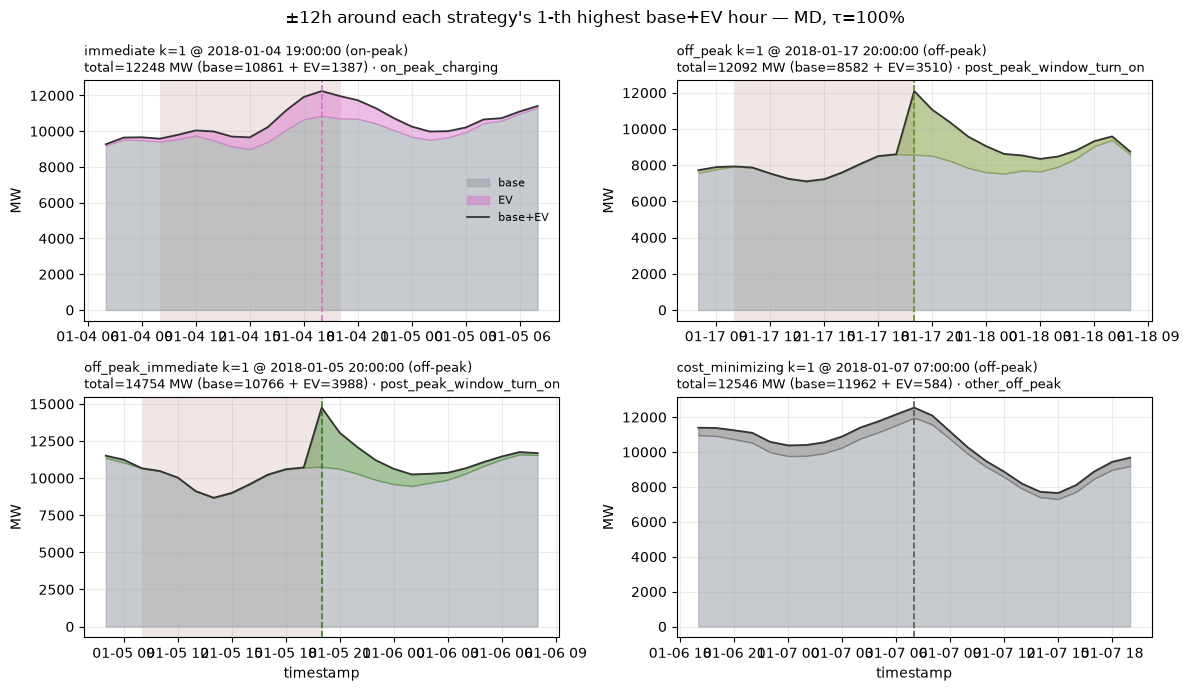

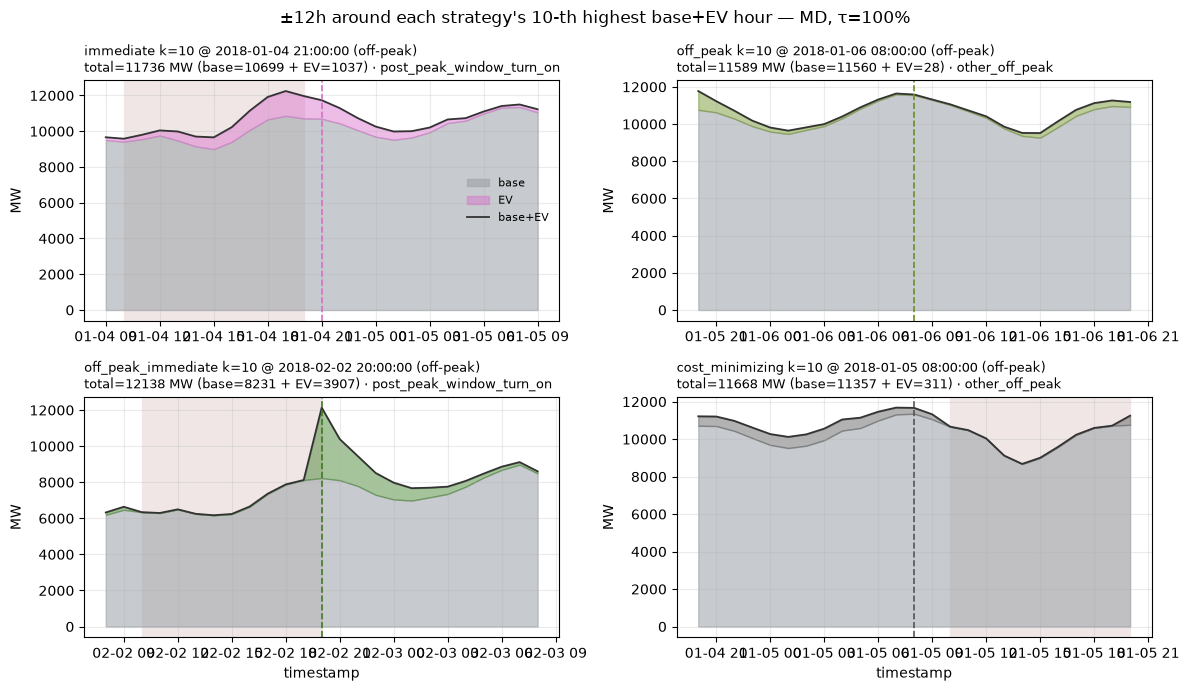

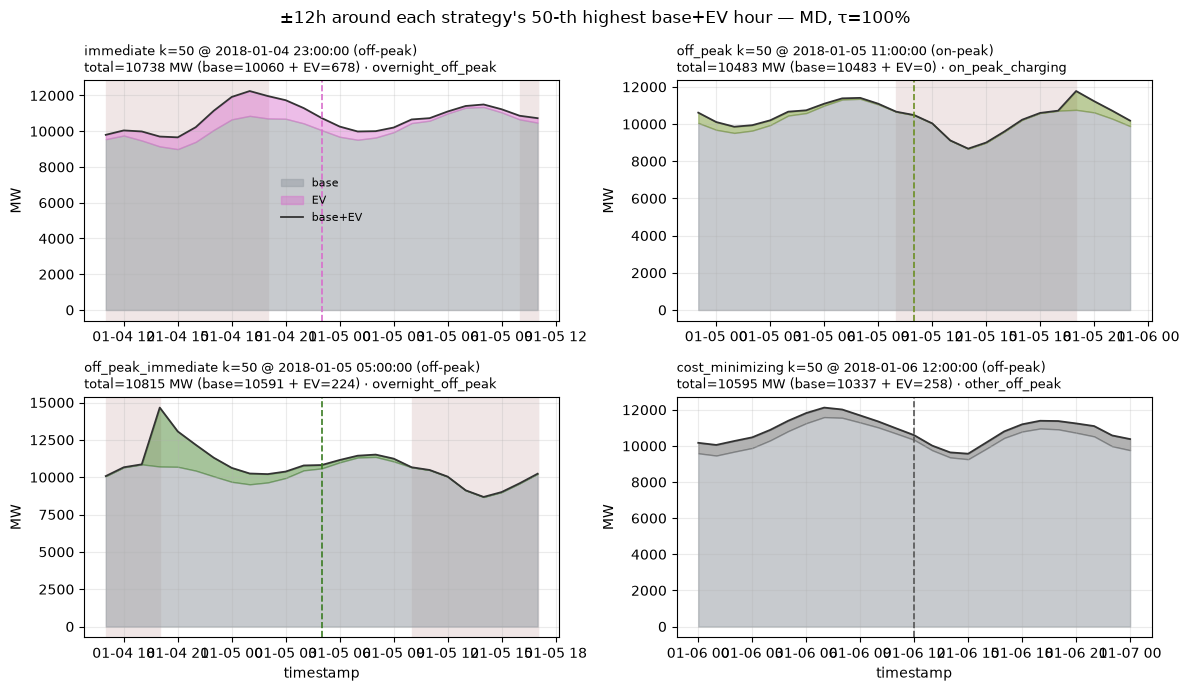

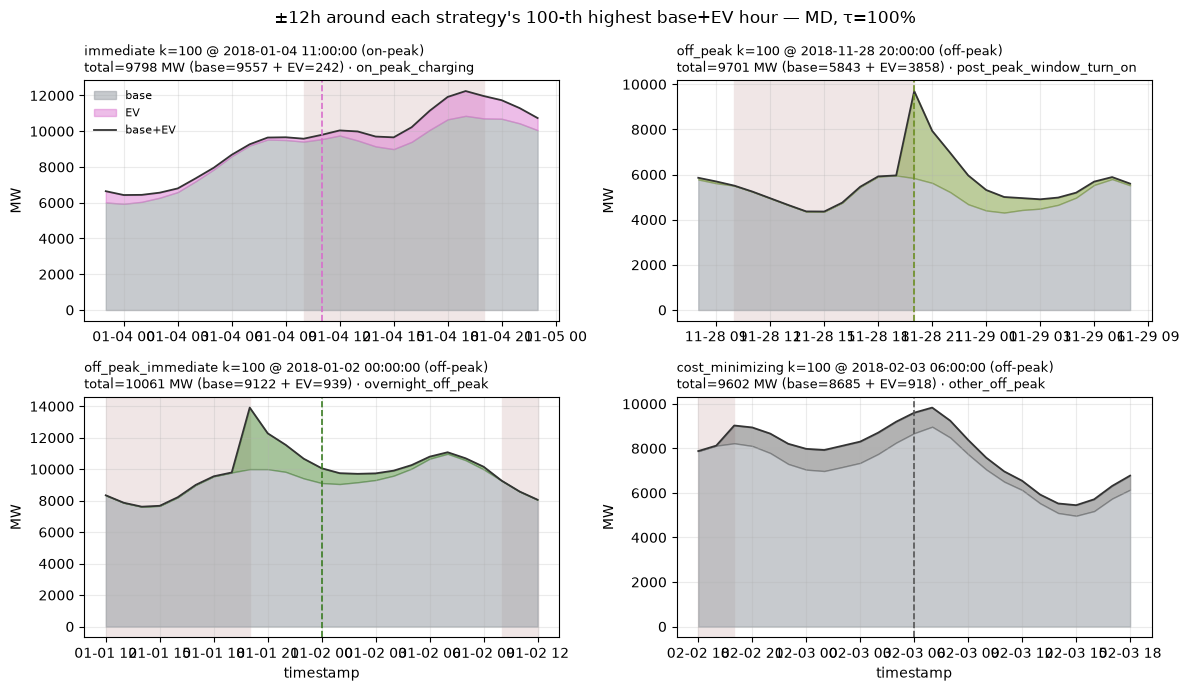

In [15]:
# --- Base + EV k-th peak-hour forensics at τ=100% ---
TOTAL_DIAG_TAU = 1.0
TOTAL_DIAG_Ks = DIAG_Ks if "DIAG_Ks" in globals() else (1, 10, 50, 100)
valid_base = np.isfinite(base_load)

ev_ids = ev_ids_by_tau[float(TOTAL_DIAG_TAU)]
rows = [bldg_id_to_row[b] for b in ev_ids if b in bldg_id_to_row]
idx = np.asarray(rows, dtype=np.int64)

total_kth_diag_rows = []
total_kth_idx: dict[tuple[str, int], int] = {}
ev_load_by_s: dict[str, np.ndarray] = {}
total_by_s: dict[str, np.ndarray] = {}

for strategy in CHARGING_STRATEGIES:
    ev_load = weights[idx] @ charge_by_strategy[strategy][idx]
    total = base_load + ev_load
    ev_load_by_s[strategy] = ev_load
    total_by_s[strategy] = total
    finite_idx = np.flatnonzero(valid_base)
    order_local = np.argsort(total[finite_idx])[::-1]
    for k in TOTAL_DIAG_Ks:
        peak_idx = int(finite_idx[order_local[k - 1]])
        total_kth_idx[(strategy, k)] = peak_idx
        ctx = _hour_context(peak_idx)
        base_only_idx = int(np.nanargmax(base_load))
        total_kth_diag_rows.append(
            {
                "strategy": strategy,
                "k": k,
                "timestamp": ctx["timestamp"],
                "weekday": ctx["weekday"],
                "clock_hour": ctx["clock_hour"],
                "tou_label": ctx["tou_label"],
                "price_usd_per_kwh": ctx["price_usd_per_kwh"],
                "mechanism": _mechanism_tag(ctx),
                "peak_total_mw": float(total[peak_idx]) / 1000.0,
                "base_at_peak_mw": float(base_load[peak_idx]) / 1000.0,
                "ev_at_peak_mw": float(ev_load[peak_idx]) / 1000.0,
                "ev_share_of_peak": float(ev_load[peak_idx] / total[peak_idx])
                if total[peak_idx] > 0
                else 0.0,
                "same_hour_as_base_only_peak": peak_idx == base_only_idx,
            }
        )

total_kth_diag_df = pl.DataFrame(total_kth_diag_rows)
print(f"Combined (base+EV) k-th hour forensics @ τ={TOTAL_DIAG_TAU:.0%}")
display(total_kth_diag_df)

print("\nMechanism tags by strategy × k (base+EV):")
display(
    total_kth_diag_df.pivot(on="k", index="strategy", values="mechanism").sort("strategy")
)

# ±12h stack: one 2×2 figure per k
for k in TOTAL_DIAG_Ks:
    fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey=False)
    axes = axes.ravel()
    for ax, strategy in zip(axes, CHARGING_STRATEGIES):
        peak_idx = total_kth_idx[(strategy, k)]
        lo = max(0, peak_idx - DIAG_WINDOW_H)
        hi = min(n_hours, peak_idx + DIAG_WINDOW_H + 1)
        xs = timestamps[lo:hi]
        base_seg = base_load[lo:hi] / 1000.0
        ev_seg = ev_load_by_s[strategy][lo:hi] / 1000.0
        total_seg = total_by_s[strategy][lo:hi] / 1000.0

        ax.fill_between(xs, 0, base_seg, color="#9AA0A6", alpha=0.55, label="base")
        ax.fill_between(
            xs,
            base_seg,
            base_seg + ev_seg,
            color=STRATEGY_COLORS[strategy],
            alpha=0.45,
            label="EV",
        )
        ax.plot(xs, total_seg, color="#333333", linewidth=1.3, label="base+EV")
        ax.axvline(
            timestamps[peak_idx],
            color=STRATEGY_COLORS[strategy],
            linestyle="--",
            linewidth=1.2,
        )
        for j in range(lo, hi):
            if not is_off_peak[j]:
                ax.axvspan(
                    timestamps[j],
                    timestamps[min(j + 1, hi - 1)],
                    color="#f0e6e6",
                    zorder=0,
                )
        ctx = _hour_context(peak_idx)
        ax.set_title(
            f"{strategy} k={k} @ {timestamps[peak_idx]} ({ctx['tou_label']})\n"
            f"total={total_by_s[strategy][peak_idx]/1000:.0f} MW "
            f"(base={base_load[peak_idx]/1000:.0f} + "
            f"EV={ev_load_by_s[strategy][peak_idx]/1000:.0f}) · {_mechanism_tag(ctx)}",
            loc="left",
            fontsize=9,
        )
        ax.set_ylabel("MW")
        ax.grid(True, alpha=0.25)

    axes[0].legend(frameon=False, fontsize=8)
    axes[2].set_xlabel("timestamp")
    axes[3].set_xlabel("timestamp")
    fig.suptitle(
        f"±{DIAG_WINDOW_H}h around each strategy's {k}-th highest base+EV hour — "
        f"{STATE}, τ={TOTAL_DIAG_TAU:.0%}",
        fontsize=12,
    )
    fig.tight_layout()
    plt.show()


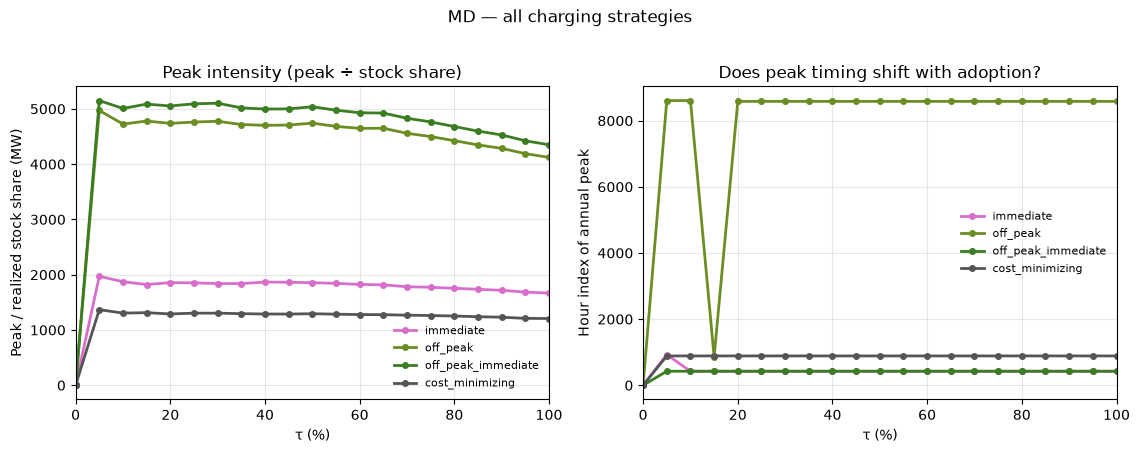


[immediate]
  τ=5%: peak=98.74 MW at 2018-02-08 19:00:00 (n_ev=451)
  τ=25%: peak=463.39 MW at 2018-01-18 19:00:00 (n_ev=2,251)
  τ=50%: peak=927.48 MW at 2018-01-18 19:00:00 (n_ev=4,501)
  τ=75%: peak=1329.47 MW at 2018-01-18 19:00:00 (n_ev=6,751)
  τ=100%: peak=1667.84 MW at 2018-01-18 19:00:00 (n_ev=9,001)

[off_peak]
  τ=5%: peak=249.11 MW at 2018-12-25 20:00:00 (n_ev=451)
  τ=25%: peak=1190.82 MW at 2018-12-24 20:00:00 (n_ev=2,251)
  τ=50%: peak=2371.25 MW at 2018-12-24 20:00:00 (n_ev=4,501)
  τ=75%: peak=3374.72 MW at 2018-12-24 20:00:00 (n_ev=6,751)
  τ=100%: peak=4123.19 MW at 2018-12-24 20:00:00 (n_ev=9,001)

[off_peak_immediate]
  τ=5%: peak=258.06 MW at 2018-01-18 20:00:00 (n_ev=451)
  τ=25%: peak=1273.39 MW at 2018-01-18 20:00:00 (n_ev=2,251)
  τ=50%: peak=2519.54 MW at 2018-01-18 20:00:00 (n_ev=4,501)
  τ=75%: peak=3573.63 MW at 2018-01-18 20:00:00 (n_ev=6,751)
  τ=100%: peak=4351.02 MW at 2018-01-18 20:00:00 (n_ev=9,001)

[cost_minimizing]
  τ=5%: peak=68.53 MW at 2018-0

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))

# Peak per unit stock share (linearity): flat ⇒ peak scales with τ
ax = axes[0]
for strategy in CHARGING_STRATEGIES:
    sub = peak_df.filter(pl.col("strategy") == strategy).sort("adoption_rate")
    x = sub["adoption_rate"].to_numpy() * 100
    y_norm = sub["peak_per_stock_share_kwh"].to_numpy() / 1000.0
    ax.plot(
        x,
        y_norm,
        color=STRATEGY_COLORS[strategy],
        marker="o",
        linewidth=2,
        markersize=4,
        label=STRATEGY_LABELS[strategy],
    )
ax.set_xlabel("τ (%)")
ax.set_ylabel("Peak / realized stock share (MW)")
ax.set_title("Peak intensity (peak ÷ stock share)")
ax.set_xlim(0, 100)
ax.grid(True, alpha=0.3)
ax.legend(frameon=False, fontsize=8)

# When does the annual peak occur?
ax = axes[1]
for strategy in CHARGING_STRATEGIES:
    sub = peak_df.filter(pl.col("strategy") == strategy).sort("adoption_rate")
    ax.plot(
        sub["adoption_rate"].to_numpy() * 100,
        sub["peak_hour_index"].to_numpy(),
        color=STRATEGY_COLORS[strategy],
        marker="o",
        linewidth=2,
        markersize=4,
        label=STRATEGY_LABELS[strategy],
    )
ax.set_xlabel("τ (%)")
ax.set_ylabel("Hour index of annual peak")
ax.set_title("Does peak timing shift with adoption?")
ax.set_xlim(0, 100)
ax.grid(True, alpha=0.3)
ax.legend(frameon=False, fontsize=8)

fig.suptitle(f"{STATE} — all charging strategies", y=1.02)
fig.tight_layout()
plt.show()

# Print peak timestamps at milestones for each strategy
for strategy in CHARGING_STRATEGIES:
    print(f"\n[{strategy}]")
    for tau in (0.05, 0.25, 0.50, 0.75, 1.00):
        row = peak_df.filter(
            (pl.col("strategy") == strategy) & (pl.col("adoption_rate") == tau)
        )
        if row.height:
            print(
                f"  τ={tau:.0%}: peak={row['peak_charge_mw'][0]:.2f} MW at "
                f"{row['peak_timestamp'][0]} (n_ev={row['n_ev_with_charge'][0]:,})"
            )


## 4. TOU bill savings — Schedule R vs Schedule EV

SOS **supply-only** bills (excludes delivery), same Rider 1 filing as the YAML TOU prices:
[BGE Rider 1 – Market-Priced Service Rate Components](https://azure-na-assets.contentstack.com/v3/assets/blt71bfe6e8a1c2d265/blt970ee32f55c20fde/Rdr_1.pdf)
(transmission rates effective Jun 1, 2026).

| Tariff | Within-day | Notes |
|---|---|---|
| **Schedule R** | flat | **summer SOS rate year-round**: \$0.14747/kWh |
| **Schedule EV** | on/off-peak (weekdays 10am–8pm) | **summer SOS rates year-round**: on \$0.23636 / off \$0.09981; weekends off-peak; holidays not special |

**Adoption scenarios** (weight-weighted charge from the cache):

- **current** — baseline Bernoulli ResStock P(EV) (`target_adoption_rate=None`, ~1–2% MD)
- **25%** / **50%** — nested priority-sampled stock shares from §2

**Comparisons** (within each scenario):

1. Schedule R + Immediate (`immediate`) — non-TOU status quo
2. Schedule EV + Immediate — price-only effect (same charging shape)
3. Schedule EV + TOU Immediate (`off_peak_immediate`) — price + behavior

Also report on-peak vs off-peak kWh, charging hours on-peak, and effective ¢/kWh
(bill ÷ kWh charged). Annual kWh charged differs slightly between strategies because
end-of-year SOC (and any underflow clamping) depends on when charging is allowed.


Current (baseline Bernoulli) adoption: n_ev=178  realized_stock_share=1.98%

SOS bill diagnostics — current  (current (baseline P(EV)))
  n_ev=178  realized_stock_share=1.98%  (weight-weighted charge)
Schedule R: $0.14747/kWh  (summer rate, flat year-round)
Schedule EV: year-round summer SOS on=$0.23636/kWh  off=$0.09981/kWh  (weekdays peak hours; weekends off-peak; no holiday exemption)
Status quo bill (R + Immediate) = $12,747,565/yr

=== Charge timing + bills by strategy ===


strategy,annual_charge_kwh,on_peak_kwh,off_peak_kwh,on_peak_kwh_share,veh_hours_charging,veh_hours_on_peak,veh_hours_on_peak_share,bill_schedule_r_usd,bill_schedule_ev_usd,effective_r_usd_per_kwh,effective_ev_usd_per_kwh,bill_r_per_ev_usd,bill_ev_per_ev_usd
str,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64
"""Immediate""",8.6442e7,3.5178e7,5.1263e7,0.40696,180412,65922,0.365397,1.2748e7,1.3431e7,0.14747,0.15538,71615.534924,75457.032364
"""TOU Immediate""",8.6430e7,0.0,8.6430e7,0.0,176868,0,0.0,1.2746e7,8.6265e6,0.14747,0.09981,71605.417313,48463.665166



=== Savings vs Schedule R + Immediate (billed at Schedule EV unless noted) ===


strategy,bill_schedule_r_usd,bill_schedule_ev_usd,savings_vs_R_immediate_usd,savings_vs_R_immediate_pct,price_only_delta_usd,behavior_vs_imm_on_EV_usd,on_peak_kwh_avoided_vs_imm,annual_charge_kwh,on_peak_kwh_share,effective_ev_cents_per_kwh,bill_ev_per_ev_usd
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Immediate""",1.2748e7,1.3431e7,-683786.544199,-5.364056,-683786.544199,0.0,0.0,8.6442e7,0.40696,15.538037,75457.032364
"""TOU Immediate""",1.2746e7,8.6265e6,4.1210e6,32.327999,4.1192e6,4.8048e6,3.5178e7,8.6430e7,0.0,9.981,48463.665166


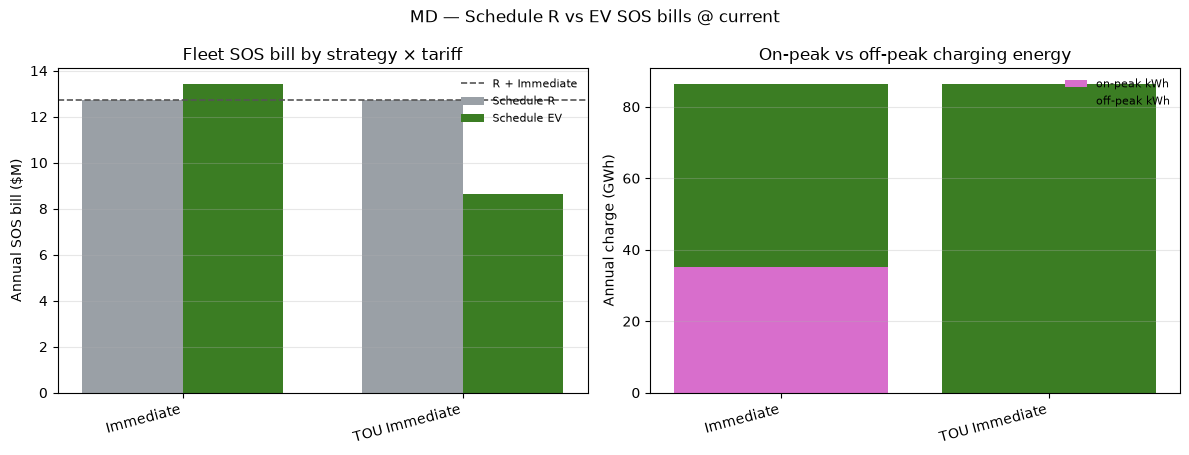

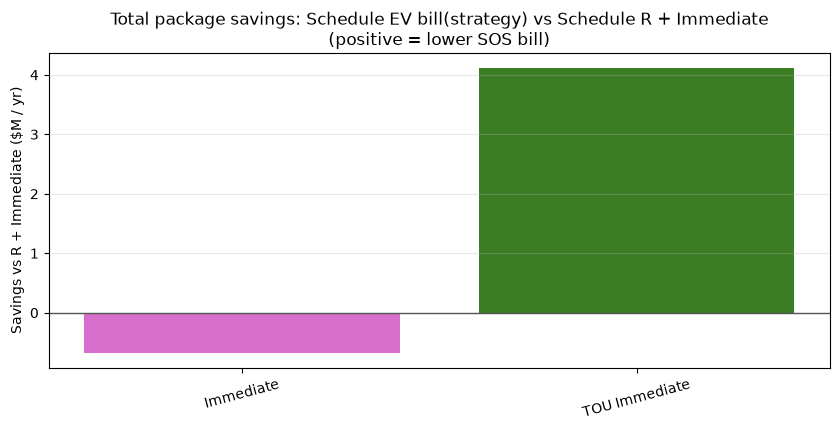


=== Headline comparisons ===
1) Price-only (Immediate on EV vs R): $-683,787/yr (-5.4% of R+Immediate bill)
2) TOU Immediate on EV vs R+Immediate: $4,121,033/yr (32.3%); on-peak kWh avoided vs Immediate=35,178,326; behavior vs Immediate on EV=$4,804,819

SOS bill diagnostics — 25%  (τ=25%)
  n_ev=2,251  realized_stock_share=25.01%  (weight-weighted charge)
Schedule R: $0.14747/kWh  (summer rate, flat year-round)
Schedule EV: year-round summer SOS on=$0.23636/kWh  off=$0.09981/kWh  (weekdays peak hours; weekends off-peak; no holiday exemption)
Status quo bill (R + Immediate) = $161,655,909/yr

=== Charge timing + bills by strategy ===


strategy,annual_charge_kwh,on_peak_kwh,off_peak_kwh,on_peak_kwh_share,veh_hours_charging,veh_hours_on_peak,veh_hours_on_peak_share,bill_schedule_r_usd,bill_schedule_ev_usd,effective_r_usd_per_kwh,effective_ev_usd_per_kwh,bill_r_per_ev_usd,bill_ev_per_ev_usd
str,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64
"""Immediate""",1.0962e9,4.4776e8,6.4843e8,0.408469,2317401,889996,0.384049,1.6166e8,1.7055e8,0.14747,0.155586,71815.152748,75767.690695
"""TOU Immediate""",1.0960e9,76699.699167,1.0959e9,0.00007,2279687,183,0.00008,1.6163e8,1.0940e8,0.14747,0.09982,71802.715493,48601.852408



=== Savings vs Schedule R + Immediate (billed at Schedule EV unless noted) ===


strategy,bill_schedule_r_usd,bill_schedule_ev_usd,savings_vs_R_immediate_usd,savings_vs_R_immediate_pct,price_only_delta_usd,behavior_vs_imm_on_EV_usd,on_peak_kwh_avoided_vs_imm,annual_charge_kwh,on_peak_kwh_share,effective_ev_cents_per_kwh,bill_ev_per_ev_usd
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Immediate""",1.6166e8,1.7055e8,-8.8972e6,-5.503766,-8.8972e6,0.0,0.0,1.0962e9,0.408469,15.55864,75767.690695
"""TOU Immediate""",1.6163e8,1.0940e8,5.2253e7,32.32368,5.2225e7,6.1150e7,4.4768e8,1.0960e9,0.00007,9.981956,48601.852408


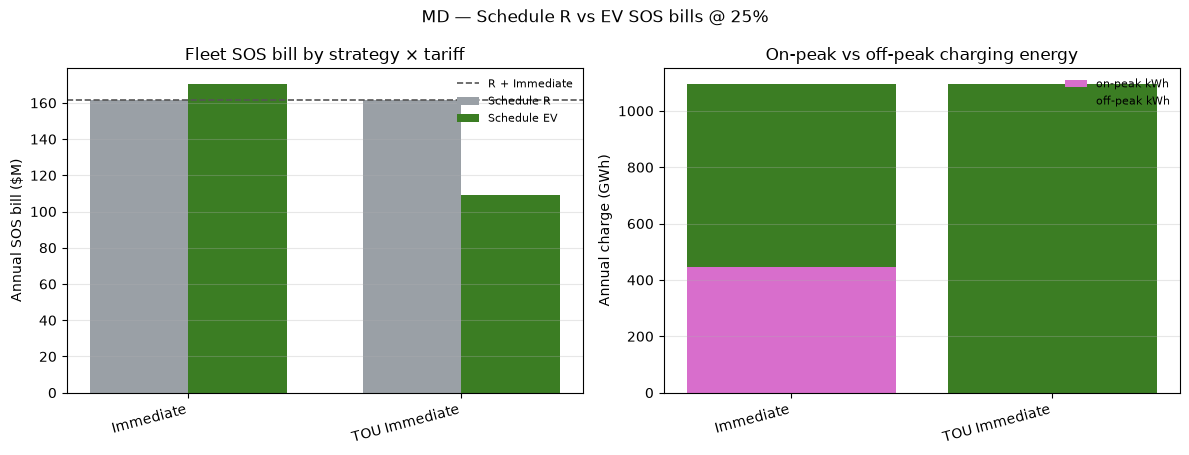

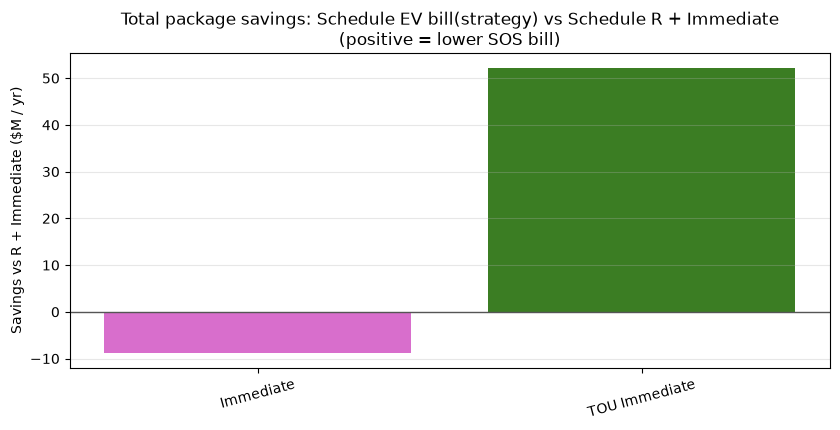


=== Headline comparisons ===
1) Price-only (Immediate on EV vs R): $-8,897,163/yr (-5.5% of R+Immediate bill)
2) TOU Immediate on EV vs R+Immediate: $52,253,139/yr (32.3%); on-peak kWh avoided vs Immediate=447,684,758; behavior vs Immediate on EV=$61,150,302



SOS bill diagnostics — 50%  (τ=50%)
  n_ev=4,501  realized_stock_share=50.01%  (weight-weighted charge)
Schedule R: $0.14747/kWh  (summer rate, flat year-round)
Schedule EV: year-round summer SOS on=$0.23636/kWh  off=$0.09981/kWh  (weekdays peak hours; weekends off-peak; no holiday exemption)
Status quo bill (R + Immediate) = $323,047,930/yr

=== Charge timing + bills by strategy ===


strategy,annual_charge_kwh,on_peak_kwh,off_peak_kwh,on_peak_kwh_share,veh_hours_charging,veh_hours_on_peak,veh_hours_on_peak_share,bill_schedule_r_usd,bill_schedule_ev_usd,effective_r_usd_per_kwh,effective_ev_usd_per_kwh,bill_r_per_ev_usd,bill_ev_per_ev_usd
str,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64
"""Immediate""",2.1906e9,9.0060e8,1.2900e9,0.411119,4635890,1791769,0.386499,3.2305e8,3.4162e8,0.14747,0.155948,71772.479481,75898.788448
"""TOU Immediate""",2.1902e9,238778.274076,2.1900e9,0.000109,4562936,574,0.000126,3.2299e8,2.1864e8,0.14747,0.099825,71758.979028,48574.842118



=== Savings vs Schedule R + Immediate (billed at Schedule EV unless noted) ===


strategy,bill_schedule_r_usd,bill_schedule_ev_usd,savings_vs_R_immediate_usd,savings_vs_R_immediate_pct,price_only_delta_usd,behavior_vs_imm_on_EV_usd,on_peak_kwh_avoided_vs_imm,annual_charge_kwh,on_peak_kwh_share,effective_ev_cents_per_kwh,bill_ev_per_ev_usd
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Immediate""",3.2305e8,3.4162e8,-1.8573e7,-5.749152,-1.8573e7,0.0,0.0,2.1906e9,0.411119,15.594827,75898.788448
"""TOU Immediate""",3.2299e8,2.1864e8,1.0441e8,32.321076,1.0435e8,1.2299e8,9.0036e8,2.1902e9,0.000109,9.982489,48574.842118


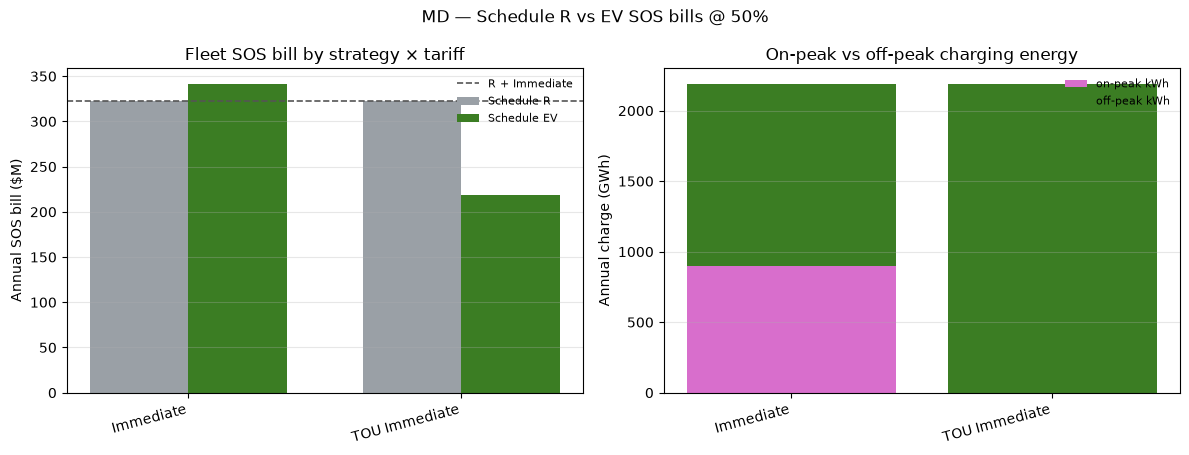

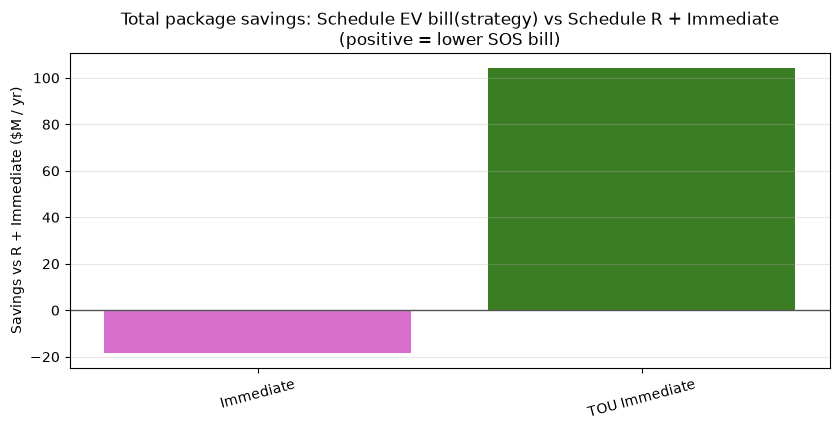


=== Headline comparisons ===
1) Price-only (Immediate on EV vs R): $-18,572,517/yr (-5.7% of R+Immediate bill)
2) TOU Immediate on EV vs R+Immediate: $104,412,566/yr (32.3%); on-peak kWh avoided vs Immediate=900,358,516; behavior vs Immediate on EV=$122,985,082

=== Cross-scenario summary ===


scenario,tau,n_ev,bill_R_immediate_usd,bill_EV_immediate_usd,best_strategy,best_bill_EV_usd,best_savings_vs_R_imm_usd,best_savings_vs_R_imm_pct
str,f64,i64,f64,f64,str,f64,f64,f64
"""current""",NaN,178,1.2748e7,1.3431e7,"""TOU Immediate""",8.6265e6,4.1210e6,32.327999
"""25%""",0.25,2251,1.6166e8,1.7055e8,"""TOU Immediate""",1.0940e8,5.2253e7,32.32368
"""50%""",0.5,4501,3.2305e8,3.4162e8,"""TOU Immediate""",2.1864e8,1.0441e8,32.321076


In [ ]:
# --- Schedule R vs Schedule EV bill diagnostics (current / 25% / 50%) ---
# Rider 1 Total SOS rates (¢/kWh → $/kWh), transmission effective Jun 1, 2026.
# https://azure-na-assets.contentstack.com/v3/assets/blt71bfe6e8a1c2d265/blt970ee32f55c20fde/Rdr_1.pdf
# Presentation subset: Immediate vs TOU Immediate only.
# Summer rate applied year-round, matching the Schedule EV treatment in md_2024.yaml.
SCHEDULE_R_USD_PER_KWH = 0.14747  # Jun 1 – Sep 30 rate, used for every hour

CHARGE_EPS = 1e-3

PLOT_STRATEGIES = ["immediate", "off_peak_immediate"]
PLOT_LABELS = {
    "immediate": "Immediate",
    "off_peak_immediate": "TOU Immediate",
}

# (label, τ) — τ=None → baseline Bernoulli ResStock P(EV) ("current")
BILL_SCENARIOS: list[tuple[str, float | None]] = [
    ("current", None),
    ("25%", 0.25),
    ("50%", 0.50),
]

price_r = np.full(hours_base.height, SCHEDULE_R_USD_PER_KWH, dtype=np.float64)

price_ev = resolve_hourly_prices(config)
if price_ev is None:
    raise RuntimeError("Schedule EV hourly prices missing — check md_2024.yaml TOU prices")
price_ev = np.asarray(price_ev, dtype=np.float64)

tou_kwargs = config.peak_window_kwargs()
is_off_peak = np.asarray(build_is_off_peak(hours_base, **tou_kwargs), dtype=bool)
is_on_peak = ~is_off_peak

# Baseline ("current") EV set — same seed as the nested sweep, Bernoulli(p_i)
_baseline_sampled = EVAdoptionSampler(
    ev_ownership_df=inputs.ev_ownership_df,
    random_state=SEED,
    target_adoption_rate=None,
).sample(metadata_df)
ev_ids_current = set(
    _baseline_sampled.filter(pl.col("evs") == 1)["bldg_id"].to_list()
)
_w_current = float(
    metadata_df.filter(pl.col("bldg_id").is_in(list(ev_ids_current)))["weight"].sum()
)
print(
    f"Current (baseline Bernoulli) adoption: n_ev={len(ev_ids_current):,}  "
    f"realized_stock_share={_w_current / total_weight:.2%}"
)


def _ev_ids_for_bill_tau(tau: float | None) -> set[int]:
    if tau is None:
        return ev_ids_current
    return ev_ids_by_tau[float(tau)]


def _bill_tables_for_tau(tau: float | None) -> tuple[pl.DataFrame, pl.DataFrame, dict]:
    ev_ids_bill = _ev_ids_for_bill_tau(tau)
    row_idx_bill = np.asarray(
        [bldg_id_to_row[b] for b in ev_ids_bill if b in bldg_id_to_row], dtype=np.int64
    )
    w_bill = weights[row_idx_bill]
    n_ev_bill = len(row_idx_bill)
    stock_w = float(w_bill.sum()) if n_ev_bill else 0.0
    realized = stock_w / total_weight if total_weight > 0 else 0.0

    def _fleet_charge_kwh(strategy: str) -> np.ndarray:
        if n_ev_bill == 0:
            return np.zeros(hours_base.height, dtype=np.float64)
        return w_bill @ charge_by_strategy[strategy][row_idx_bill]

    bill_rows = []
    for strategy in PLOT_STRATEGIES:
        load = _fleet_charge_kwh(strategy)  # kWh / hour, weight-weighted
        total_kwh = float(load.sum())
        on_kwh = float(load[is_on_peak].sum())
        off_kwh = float(load[is_off_peak].sum())
        bill_r = float((load * price_r).sum())
        bill_ev = float((load * price_ev).sum())

        if n_ev_bill == 0:
            veh_hours = veh_hours_on = veh_hours_off = 0
        else:
            mat = charge_by_strategy[strategy][row_idx_bill]
            charging = mat > CHARGE_EPS
            veh_hours = int(charging.sum())
            veh_hours_on = int(charging[:, is_on_peak].sum())
            veh_hours_off = int(charging[:, is_off_peak].sum())

        bill_rows.append(
            {
                "strategy": strategy,
                "annual_charge_kwh": total_kwh,
                "on_peak_kwh": on_kwh,
                "off_peak_kwh": off_kwh,
                "on_peak_kwh_share": on_kwh / total_kwh if total_kwh > 0 else 0.0,
                "veh_hours_charging": veh_hours,
                "veh_hours_on_peak": veh_hours_on,
                "veh_hours_on_peak_share": veh_hours_on / veh_hours if veh_hours else 0.0,
                "bill_schedule_r_usd": bill_r,
                "bill_schedule_ev_usd": bill_ev,
                "effective_r_usd_per_kwh": bill_r / total_kwh if total_kwh > 0 else float("nan"),
                "effective_ev_usd_per_kwh": bill_ev / total_kwh if total_kwh > 0 else float("nan"),
                "bill_r_per_ev_usd": bill_r / n_ev_bill if n_ev_bill else float("nan"),
                "bill_ev_per_ev_usd": bill_ev / n_ev_bill if n_ev_bill else float("nan"),
            }
        )

    bill_df = pl.DataFrame(bill_rows)
    sq = bill_df.filter(pl.col("strategy") == "immediate").row(0, named=True)
    sq_bill_r = float(sq["bill_schedule_r_usd"])
    imm_on_kwh = float(sq["on_peak_kwh"])

    comp_rows = []
    for row in bill_df.iter_rows(named=True):
        bill_ev = float(row["bill_schedule_ev_usd"])
        bill_r = float(row["bill_schedule_r_usd"])
        comp_rows.append(
            {
                "strategy": row["strategy"],
                "bill_schedule_r_usd": bill_r,
                "bill_schedule_ev_usd": bill_ev,
                "savings_vs_R_immediate_usd": sq_bill_r - bill_ev,
                "savings_vs_R_immediate_pct": 100.0 * (sq_bill_r - bill_ev) / sq_bill_r
                if sq_bill_r > 0
                else float("nan"),
                "price_only_delta_usd": bill_r - bill_ev,
                "behavior_vs_imm_on_EV_usd": float(sq["bill_schedule_ev_usd"]) - bill_ev
                if row["strategy"] != "immediate"
                else 0.0,
                "on_peak_kwh_avoided_vs_imm": imm_on_kwh - float(row["on_peak_kwh"]),
                "annual_charge_kwh": row["annual_charge_kwh"],
                "on_peak_kwh_share": row["on_peak_kwh_share"],
                "effective_ev_cents_per_kwh": 100.0 * float(row["effective_ev_usd_per_kwh"]),
                "bill_ev_per_ev_usd": row["bill_ev_per_ev_usd"],
            }
        )
    comp_df = pl.DataFrame(comp_rows)
    meta = {
        "n_ev_bill": n_ev_bill,
        "realized": realized,
        "sq_bill_r": sq_bill_r,
        "sq": sq,
    }
    return bill_df, comp_df, meta


def _plot_bill_scenario(
    label: str,
    tau: float | None,
    bill_df: pl.DataFrame,
    comp_df: pl.DataFrame,
    meta: dict,
) -> None:
    n_ev_bill = meta["n_ev_bill"]
    realized = meta["realized"]
    sq_bill_r = meta["sq_bill_r"]
    tau_txt = "current (baseline P(EV))" if tau is None else f"τ={tau:.0%}"

    print(
        f"\n{'=' * 72}\n"
        f"SOS bill diagnostics — {label}  ({tau_txt})\n"
        f"  n_ev={n_ev_bill:,}  realized_stock_share={realized:.2%}  "
        f"(weight-weighted charge)\n"
        f"Schedule R: ${SCHEDULE_R_USD_PER_KWH:.5f}/kWh  "
        f"(summer rate, flat year-round)\n"
        f"Schedule EV: year-round summer SOS on=${float(np.nanmax(price_ev)):.5f}/kWh  "
        f"off=${float(np.nanmin(price_ev)):.5f}/kWh  "
        f"(weekdays peak hours; weekends off-peak; no holiday exemption)\n"
        f"Status quo bill (R + Immediate) = ${sq_bill_r:,.0f}/yr"
    )
    print("\n=== Charge timing + bills by strategy ===")
    display(bill_df.with_columns(pl.col("strategy").replace(PLOT_LABELS)))
    print("\n=== Savings vs Schedule R + Immediate (billed at Schedule EV unless noted) ===")
    display(comp_df.with_columns(pl.col("strategy").replace(PLOT_LABELS)))

    strategies = list(PLOT_STRATEGIES)
    strategy_labels = [PLOT_LABELS[s] for s in strategies]
    x = np.arange(len(strategies))
    width = 0.36
    bill_scale = 1e6 if sq_bill_r >= 1e6 else 1e3
    bill_unit = "$M" if bill_scale == 1e6 else "$k"
    energy_scale = 1e6 if float(bill_df["annual_charge_kwh"].max()) >= 1e6 else 1e3
    energy_unit = "GWh" if energy_scale == 1e6 else "MWh"

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

    ax = axes[0]
    bills_r = [float(bill_df.filter(pl.col("strategy") == s)["bill_schedule_r_usd"][0]) for s in strategies]
    bills_e = [float(bill_df.filter(pl.col("strategy") == s)["bill_schedule_ev_usd"][0]) for s in strategies]
    ax.bar(x - width / 2, np.asarray(bills_r) / bill_scale, width, color="#9AA0A6", label="Schedule R")
    ax.bar(x + width / 2, np.asarray(bills_e) / bill_scale, width, color=COLOR_GREEN, label="Schedule EV")
    ax.axhline(sq_bill_r / bill_scale, color="#555555", linestyle="--", linewidth=1.2, label="R + Immediate")
    ax.set_xticks(x)
    ax.set_xticklabels(strategy_labels, rotation=15, ha="right")
    ax.set_ylabel(f"Annual SOS bill ({bill_unit})")
    ax.set_title("Fleet SOS bill by strategy × tariff")
    ax.legend(frameon=False, fontsize=8)
    ax.grid(True, axis="y", alpha=0.3)

    ax = axes[1]
    on_k = [float(bill_df.filter(pl.col("strategy") == s)["on_peak_kwh"][0]) for s in strategies]
    off_k = [float(bill_df.filter(pl.col("strategy") == s)["off_peak_kwh"][0]) for s in strategies]
    ax.bar(x, np.asarray(on_k) / energy_scale, color=COLOR_PINK, label="on-peak kWh")
    ax.bar(
        x,
        np.asarray(off_k) / energy_scale,
        bottom=np.asarray(on_k) / energy_scale,
        color=COLOR_GREEN,
        label="off-peak kWh",
    )
    ax.set_xticks(x)
    ax.set_xticklabels(strategy_labels, rotation=15, ha="right")
    ax.set_ylabel(f"Annual charge ({energy_unit})")
    ax.set_title("On-peak vs off-peak charging energy")
    ax.legend(frameon=False, fontsize=8)
    ax.grid(True, axis="y", alpha=0.3)

    fig.suptitle(f"{STATE} — Schedule R vs EV SOS bills @ {label}", fontsize=12)
    fig.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8.5, 4.4))
    plot_s = list(strategies)
    savings = [
        float(comp_df.filter(pl.col("strategy") == s)["savings_vs_R_immediate_usd"][0]) / bill_scale
        for s in plot_s
    ]
    colors = [STRATEGY_COLORS[s] for s in plot_s]
    ax.bar(strategy_labels, savings, color=colors)
    ax.axhline(0.0, color="#555555", linewidth=1.0)
    ax.set_ylabel(f"Savings vs R + Immediate ({bill_unit} / yr)")
    ax.set_title(
        "Total package savings: Schedule EV bill(strategy) vs Schedule R + Immediate\n"
        "(positive = lower SOS bill)"
    )
    ax.tick_params(axis="x", rotation=15)
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()

    print("\n=== Headline comparisons ===")
    imm_ev = float(comp_df.filter(pl.col("strategy") == "immediate")["bill_schedule_ev_usd"][0])
    if sq_bill_r > 0:
        print(
            f"1) Price-only (Immediate on EV vs R): "
            f"${sq_bill_r - imm_ev:,.0f}/yr "
            f"({100 * (sq_bill_r - imm_ev) / sq_bill_r:.1f}% of R+Immediate bill)"
        )
    else:
        print("1) Price-only (Immediate on EV vs R): n/a (zero status-quo bill)")
    for s in ("off_peak_immediate",):
        row = comp_df.filter(pl.col("strategy") == s).row(0, named=True)
        pct = row["savings_vs_R_immediate_pct"]
        pct_s = f"{pct:.1f}%" if pct == pct else "n/a"
        print(
            f"2) {PLOT_LABELS[s]} on EV vs R+Immediate: "
            f"${row['savings_vs_R_immediate_usd']:,.0f}/yr "
            f"({pct_s}); "
            f"on-peak kWh avoided vs Immediate={row['on_peak_kwh_avoided_vs_imm']:,.0f}; "
            f"behavior vs Immediate on EV=${row['behavior_vs_imm_on_EV_usd']:,.0f}"
        )


bill_by_scenario: dict[str, pl.DataFrame] = {}
comp_by_scenario: dict[str, pl.DataFrame] = {}
for label, tau in BILL_SCENARIOS:
    bill_df, comp_df, meta = _bill_tables_for_tau(tau)
    bill_by_scenario[label] = bill_df.with_columns(pl.lit(label).alias("scenario"))
    comp_by_scenario[label] = comp_df.with_columns(pl.lit(label).alias("scenario"))
    _plot_bill_scenario(label, tau, bill_df, comp_df, meta)

# Cross-scenario summary (R+Immediate vs best EV package among plotted strategies)
summary_rows = []
for label, tau in BILL_SCENARIOS:
    bill_df = bill_by_scenario[label]
    comp_df = comp_by_scenario[label]
    sq = bill_df.filter(pl.col("strategy") == "immediate").row(0, named=True)
    best = comp_df.sort("savings_vs_R_immediate_usd", descending=True).row(0, named=True)
    summary_rows.append(
        {
            "scenario": label,
            "tau": tau if tau is not None else float("nan"),
            "n_ev": int(
                len(_ev_ids_for_bill_tau(tau) & set(bldg_id_to_row))
            ),
            "bill_R_immediate_usd": float(sq["bill_schedule_r_usd"]),
            "bill_EV_immediate_usd": float(sq["bill_schedule_ev_usd"]),
            "best_strategy": PLOT_LABELS.get(best["strategy"], best["strategy"]),
            "best_bill_EV_usd": float(best["bill_schedule_ev_usd"]),
            "best_savings_vs_R_imm_usd": float(best["savings_vs_R_immediate_usd"]),
            "best_savings_vs_R_imm_pct": float(best["savings_vs_R_immediate_pct"]),
        }
    )
print("\n=== Cross-scenario summary ===")
display(pl.DataFrame(summary_rows))
